## 1. What this notebook computes

**Charge conjugation is a matrix.** The author's gamma matrices are *real*. For a
*real* field ($\Psi^* = \Psi$) plain complex conjugation changes nothing: it is
the identity, and it cannot exchange matter and antimatter. Charge conjugation must
therefore be defined by a **matrix** $\mathcal{C}$:

$$\Psi^c = \mathcal{C}\, \bar\Psi^T = \mathcal{C} C \Psi^* ,$$

where $\bar\Psi = \Psi^\dagger C$ is the Dirac adjoint and $C$ the charge matrix
(the author's sigma16). This notebook finds every such matrix exactly. It

1. solves the linear equations $M(\gamma^a)^* = s\,\gamma^a M$ ($a = x1, \dots,
   x8$) for all $16 \times 16$ matrices $M = \mathcal{C}C$: for $s = +1$ (same
   mass) the solutions are the multiples of $1$, for $s = -1$ (mass reversed) the
   multiples of $\Gamma$;
2. builds the two charge-conjugation matrices $\mathcal{C}_+ = C$ and
   $\mathcal{C}_- = \Gamma C$ and checks $\mathcal{C}_+^{-1}\gamma^a\mathcal{C}_+ =
   -(\gamma^a)^T$ and $\mathcal{C}_-^{-1}\gamma^a\mathcal{C}_- = +(\gamma^a)^T$;
3. applies them to explicit solutions of the free field equation along the time
   $x4$ and shows which mass each image solves with;
4. computes how the scalar $S = \bar\Psi\Psi$ and the current $J^a = -i\bar\Psi
   \gamma^a\Psi$ change, for commuting and for anticommuting components;
5. treats **real fields**: $J = 0$, $\mathcal{C}_+$ acts as the identity, and the
   nontrivial real map is the matrix $\Gamma$ with the mass reversed;
6. checks which map preserves the anticommutator $\{\Psi, \Psi^\dagger\} =
   B\,\delta$ of the quantised field: $\Psi \to \Gamma\Psi^{\dagger T}$ does,
   $\Psi \to \Psi^{\dagger T}$ does not.

Ten checks reproduce checks of the Revision record
`Revision/lead_checks/reports/charge-conjugation-and-u1.json`. Nine teaching plots.

## 2. How to run this notebook

**Step 1. What this notebook does and what it needs.**

Notebook 05c (The charge-conjugation matrices calC_+ = C and calC_- = Gamma C) is the
file `Revision/textbook/notebooks/05c_charge_conjugation.ipynb` of the repository
Dirac_claude. It derives charge conjugation as a MATRIX map: it solves exactly the linear
equations M conj(gamma^a) = s gamma^a M for all 16 by 16 matrices M (s = +1: same mass, s
= -1: mass reversed; conj is the complex conjugate), finds the two one-dimensional
solution spaces spanned by 1 and by Gamma, builds the charge-conjugation matrices calC_+
= C and calC_- = Gamma C, checks their transposition rules, applies them to explicit
solutions of the free field equation along the time x4, computes how the bilinears S and
J change for commuting and anticommuting components, shows that for REAL fields calC_+
acts as the identity while the real matrix Gamma reverses the mass, and checks which map
preserves the canonical anticommutator of the quantised field. Nine teaching plots. It
needs a computer with Windows 11, macOS or Linux, an internet connection for the
installation, the program Git, and Python 3.12 or newer (the notebooks were built with
Python 3.14.5) with these packages at exactly these versions: numpy 2.4.6, sympy 1.14.0,
mpmath 1.3.0, matplotlib 3.11.0, jupyterlab 4.4.10, nbformat 5.10.4, nbclient 0.10.2,
ipykernel 7.1.0 and nbconvert 7.16.6. The notebook itself imports numpy, sympy and
matplotlib; the other packages run Jupyter, the program that shows and runs notebooks. It
does not need Rust.

**Step 2. Install Git and Python (once per computer).**

A terminal is the window in which you type commands: on Windows the app Windows
PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux any
terminal (it runs the shell bash). Type every command of this section into a terminal
exactly as printed, one line at a time, and press Enter after each line.

Windows: download Git from https://git-scm.com/download/win and install it with the
default choices. Download Python from https://www.python.org/downloads/ and run the
installer; in its first window tick the box "Add python.exe to PATH" before you click
"Install Now".

macOS: download Python from https://www.python.org/downloads/ and run the installer. Then
open the app Terminal and run this command, which installs Git and the compiler tools:

macOS (zsh):

    xcode-select --install

Linux (Debian or Ubuntu; other distributions have packages of the same names): run these
two commands:

Linux (bash):

    sudo apt update
    sudo apt install git python3 python3-venv

Then close the terminal and open a NEW one (a terminal opened before the installation
does not know the new programs), and check the version of Python; it must print 3.12 or a
higher number:

Windows (PowerShell):

    py -3 --version

macOS (zsh) and Linux (bash):

    python3 --version

If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
3.12 with the following three commands, and in Step 3 type `python3.12` instead of
`python3` in the command that creates the environment:

Linux (bash), only when the version is too low:

    sudo add-apt-repository ppa:deadsnakes/ppa
    sudo apt update
    sudo apt install python3.12 python3.12-venv

**Step 3. Get the repository and install the packages (once per computer).**

The commands below download the repository (about 130 MB; the folder then takes about 400
MB of disk space) into the folder Dirac_claude inside your home folder, create a private
Python environment in the folder dirac-book-env inside your home folder (a private
environment is a folder with its own copy of Python and of the packages, so that nothing
else on your computer is changed), activate it (from then on the commands `python` and
`jupyter` typed in this terminal are those of the environment, and the prompt starts with
(dirac-book-env)), and install the packages at the pinned versions (this downloads about
90 MB and takes a few minutes; the environment takes about 400 MB of disk space). If you
have done this step before, for this or for another notebook, skip it and go to Step 4;
to get the newest version of the repository, run `git pull` in the repository folder
after Step 4.

Windows (PowerShell):

    cd $HOME
    git clone https://github.com/once-ere/Dirac_claude.git
    py -3 -m venv "$HOME\dirac-book-env"
    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

The line with `Set-ExecutionPolicy` allows PowerShell to run the activation script in
this one window only; it changes nothing permanently.

macOS (zsh):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

Linux (bash):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

**Step 4. In every new terminal: activate the environment and go into the repository
folder.**

Every later step starts in the repository folder with the environment active. Run these
lines whenever you open a new terminal (they do no harm if the environment is already
active):

Windows (PowerShell):

    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    cd "$HOME\Dirac_claude"

macOS (zsh) and Linux (bash):

    source ~/dirac-book-env/bin/activate
    cd ~/Dirac_claude

**Step 5. Run the notebook in JupyterLab.**

In the repository folder, with the environment active, run these two lines (the first one
goes into the folder of the notebooks):

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter lab 05c_charge_conjugation.ipynb

JupyterLab opens in your web browser and shows the notebook (if no browser window opens,
copy the address that starts with `http://localhost:8888/lab` from the terminal into the
address bar of your browser). The name at the top right of the notebook must read Python
3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the label to its
left shows `[*]`; when it has finished, the label shows a number. The notebook has
finished when the last code cell shows a number; this takes about 25 seconds on a typical
laptop. Scroll to the end and compare the last printed lines with the lines in the step
"What the notebook writes and what you must see" below. To keep the results, save the
notebook (menu File > Save Notebook). To stop JupyterLab, choose the menu File > Shut
Down, or press Ctrl+C twice in the terminal.

**Step 6. Or run the notebook without a browser (headless).**

In the repository folder, with the environment active, run:

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter nbconvert --to notebook --execute --inplace 05c_charge_conjugation.ipynb

This runs every cell from the top to the bottom and saves the results into the notebook
file. A failed check stops it with an error message that contains AssertionError and the
name of the check. If the command ends with a line that starts with `[NbConvertApp]
Writing` and shows no error, every check passed; open the notebook with `jupyter lab
05c_charge_conjugation.ipynb` (in the same folder, without running the cells again) to
read the printed lines and see the figures.

**Step 7. What the notebook writes and what you must see.**

The notebook writes (or overwrites) these files:
`Revision/textbook/figures/05c.captions.json`,
`Revision/textbook/figures/05c_1_solution_spaces.png`,
`Revision/textbook/figures/05c_2_conjugation_matrices.png`,
`Revision/textbook/figures/05c_3_conjugate_solutions.png`,
`Revision/textbook/figures/05c_4_which_mass.png`,
`Revision/textbook/figures/05c_5_bilinears.png`,
`Revision/textbook/figures/05c_6_sign_table.png`,
`Revision/textbook/figures/05c_7_reality_in_time.png`,
`Revision/textbook/figures/05c_8_real_field.png` and
`Revision/textbook/figures/05c_9_quantum_b.png`. It changes no other file of the
repository; running it headless or saving it in JupyterLab also rewrites the notebook
file itself. It does not use the internet while it runs. The files it writes are the same
files that are stored in the repository (on another computer a figure may differ in a few
bytes, which is harmless). To get the stored versions back, run this command in the
repository folder (it also undoes every change you made yourself in the folder
Revision/textbook):

Windows, macOS and Linux:

    git checkout -- Revision/textbook

Every check of the notebook prints a line that starts with PASS. At the end of the
notebook (the output of its last code cell) you must see exactly these lines:

    PASS the nine figure files of notebook 05c exist
    ALL 19 CHECKS PASSED (notebook 05c)

and the notebook must show 9 figures below the cells that draw them.

**Step 8. If something goes wrong.**

- "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
  without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
  again. If the error remains, another Python installation has registered its own kernel
  called python3; with the environment active, run the following command and start
  JupyterLab again:

      python -m ipykernel install --user --name python3

- "FileNotFoundError: The repository folder was not found": the notebook was opened from
  a copy outside the repository. Open the file
  `Revision/textbook/notebooks/05c_charge_conjugation.ipynb` inside the folder
  Dirac_claude.
- "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
  downloaded before; skip the line with `git clone`.
- Windows: "running scripts is disabled on this system": run the line with
  `Set-ExecutionPolicy` and then the activation line again. "py is not recognized": use
  `python` instead of `py -3`; "python is not recognized": install Python again and tick
  "Add python.exe to PATH".
- Linux: "ensurepip is not available" when the environment is created: run `sudo apt
  install python3-venv` and repeat Step 3.
- "jupyter is not recognized" or "command not found: jupyter": the environment is not
  active; do Step 4 (or type `python -m jupyter` instead of `jupyter`).
- Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
  loop" and zmq: this is a message of the package pyzmq, not an error; the run continues
  normally.
- A red box with "Matplotlib is building the font cache; this may take a moment." in the
  first run after the installation: this is a message, not an error; the run continues
  and the message does not come again.
- An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
  and Run All Cells; if it fails again, install the packages again with the pip commands
  of Step 3, because a different package version can change the last digits of a result.
- "FileNotFoundError" naming Revision/algebra/gammas.json or
  Revision/lead_checks/reports/charge-conjugation-and-u1.json: the notebook was opened
  outside the repository, or the repository is incomplete; clone the repository again and
  open the notebook from its folder Revision/textbook/notebooks.

The first code cell below (the set-up cell) repeats these instructions as comments; then
it imports the packages, finds the repository folder and defines the helpers
`save_figure` (saves a figure and shows it), `check` (stops with an AssertionError when a
check fails, prints a PASS line when it passes), `report` (prints a key number as a
RESULT line) and `all_checks_passed` (prints the last line).

In [1]:
# HOW TO RUN NOTEBOOK 05c (the complete instructions)
#
# STEP 1. WHAT THIS NOTEBOOK DOES AND WHAT IT NEEDS.
#
# Notebook 05c (The charge-conjugation matrices calC_+ = C and calC_- = Gamma C) is the
# file Revision/textbook/notebooks/05c_charge_conjugation.ipynb of the repository
# Dirac_claude. It derives charge conjugation as a MATRIX map: it solves exactly the
# linear equations M conj(gamma^a) = s gamma^a M for all 16 by 16 matrices M (s = +1:
# same mass, s = -1: mass reversed; conj is the complex conjugate), finds the two
# one-dimensional solution spaces spanned by 1 and by Gamma, builds the
# charge-conjugation matrices calC_+ = C and calC_- = Gamma C, checks their transposition
# rules, applies them to explicit solutions of the free field equation along the time x4,
# computes how the bilinears S and J change for commuting and anticommuting components,
# shows that for REAL fields calC_+ acts as the identity while the real matrix Gamma
# reverses the mass, and checks which map preserves the canonical anticommutator of the
# quantised field. Nine teaching plots. It needs a computer with Windows 11, macOS or
# Linux, an internet connection for the installation, the program Git, and Python 3.12 or
# newer (the notebooks were built with Python 3.14.5) with these packages at exactly
# these versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0, jupyterlab
# 4.4.10, nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and nbconvert 7.16.6. The
# notebook itself imports numpy, sympy and matplotlib; the other packages run Jupyter,
# the program that shows and runs notebooks. It does not need Rust.
#
# STEP 2. INSTALL GIT AND PYTHON (ONCE PER COMPUTER).
#
# A terminal is the window in which you type commands: on Windows the app Windows
# PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux
# any terminal (it runs the shell bash). Type every command of this section into a
# terminal exactly as printed, one line at a time, and press Enter after each line.
#
# Windows: download Git from https://git-scm.com/download/win and install it with the
# default choices. Download Python from https://www.python.org/downloads/ and run the
# installer; in its first window tick the box "Add python.exe to PATH" before you click
# "Install Now".
#
# macOS: download Python from https://www.python.org/downloads/ and run the installer.
# Then open the app Terminal and run this command, which installs Git and the compiler
# tools:
#
# macOS (zsh):
#     xcode-select --install
#
# Linux (Debian or Ubuntu; other distributions have packages of the same names): run
# these two commands:
#
# Linux (bash):
#     sudo apt update
#     sudo apt install git python3 python3-venv
#
# Then close the terminal and open a NEW one (a terminal opened before the installation
# does not know the new programs), and check the version of Python; it must print 3.12 or
# a higher number:
#
# Windows (PowerShell):
#     py -3 --version
#
# macOS (zsh) and Linux (bash):
#     python3 --version
#
# If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
# 3.12 with the following three commands, and in Step 3 type python3.12 instead of
# python3 in the command that creates the environment:
#
# Linux (bash), only when the version is too low:
#     sudo add-apt-repository ppa:deadsnakes/ppa
#     sudo apt update
#     sudo apt install python3.12 python3.12-venv
#
# STEP 3. GET THE REPOSITORY AND INSTALL THE PACKAGES (ONCE PER COMPUTER).
#
# The commands below download the repository (about 130 MB; the folder then takes about
# 400 MB of disk space) into the folder Dirac_claude inside your home folder, create a
# private Python environment in the folder dirac-book-env inside your home folder (a
# private environment is a folder with its own copy of Python and of the packages, so
# that nothing else on your computer is changed), activate it (from then on the commands
# python and jupyter typed in this terminal are those of the environment, and the prompt
# starts with (dirac-book-env)), and install the packages at the pinned versions (this
# downloads about 90 MB and takes a few minutes; the environment takes about 400 MB of
# disk space). If you have done this step before, for this or for another notebook, skip
# it and go to Step 4; to get the newest version of the repository, run git pull in the
# repository folder after Step 4.
#
# Windows (PowerShell):
#     cd $HOME
#     git clone https://github.com/once-ere/Dirac_claude.git
#     py -3 -m venv "$HOME\dirac-book-env"
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# The line with Set-ExecutionPolicy allows PowerShell to run the activation script in
# this one window only; it changes nothing permanently.
#
# macOS (zsh):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# Linux (bash):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# STEP 4. IN EVERY NEW TERMINAL: ACTIVATE THE ENVIRONMENT AND GO INTO THE REPOSITORY
# FOLDER.
#
# Every later step starts in the repository folder with the environment active. Run these
# lines whenever you open a new terminal (they do no harm if the environment is already
# active):
#
# Windows (PowerShell):
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     cd "$HOME\Dirac_claude"
#
# macOS (zsh) and Linux (bash):
#     source ~/dirac-book-env/bin/activate
#     cd ~/Dirac_claude
#
# STEP 5. RUN THE NOTEBOOK IN JUPYTERLAB.
#
# In the repository folder, with the environment active, run these two lines (the first
# one goes into the folder of the notebooks):
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter lab 05c_charge_conjugation.ipynb
#
# JupyterLab opens in your web browser and shows the notebook (if no browser window
# opens, copy the address that starts with http://localhost:8888/lab from the terminal
# into the address bar of your browser). The name at the top right of the notebook must
# read Python 3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the
# label to its left shows [*]; when it has finished, the label shows a number. The
# notebook has finished when the last code cell shows a number; this takes about 25
# seconds on a typical laptop. Scroll to the end and compare the last printed lines with
# the lines in the step "What the notebook writes and what you must see" below. To keep
# the results, save the notebook (menu File > Save Notebook). To stop JupyterLab, choose
# the menu File > Shut Down, or press Ctrl+C twice in the terminal.
#
# STEP 6. OR RUN THE NOTEBOOK WITHOUT A BROWSER (HEADLESS).
#
# In the repository folder, with the environment active, run:
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter nbconvert --to notebook --execute --inplace 05c_charge_conjugation.ipynb
#
# This runs every cell from the top to the bottom and saves the results into the notebook
# file. A failed check stops it with an error message that contains AssertionError and
# the name of the check. If the command ends with a line that starts with [NbConvertApp]
# Writing and shows no error, every check passed; open the notebook with jupyter lab
# 05c_charge_conjugation.ipynb (in the same folder, without running the cells again) to
# read the printed lines and see the figures.
#
# STEP 7. WHAT THE NOTEBOOK WRITES AND WHAT YOU MUST SEE.
#
# The notebook writes (or overwrites) these files:
# Revision/textbook/figures/05c.captions.json,
# Revision/textbook/figures/05c_1_solution_spaces.png,
# Revision/textbook/figures/05c_2_conjugation_matrices.png,
# Revision/textbook/figures/05c_3_conjugate_solutions.png,
# Revision/textbook/figures/05c_4_which_mass.png,
# Revision/textbook/figures/05c_5_bilinears.png,
# Revision/textbook/figures/05c_6_sign_table.png,
# Revision/textbook/figures/05c_7_reality_in_time.png,
# Revision/textbook/figures/05c_8_real_field.png and
# Revision/textbook/figures/05c_9_quantum_b.png. It changes no other file of the
# repository; running it headless or saving it in JupyterLab also rewrites the notebook
# file itself. It does not use the internet while it runs. The files it writes are the
# same files that are stored in the repository (on another computer a figure may differ
# in a few bytes, which is harmless). To get the stored versions back, run this command
# in the repository folder (it also undoes every change you made yourself in the folder
# Revision/textbook):
#
# Windows, macOS and Linux:
#     git checkout -- Revision/textbook
#
# Every check of the notebook prints a line that starts with PASS. At the end of the
# notebook (the output of its last code cell) you must see exactly these lines:
#
#     PASS the nine figure files of notebook 05c exist
#     ALL 19 CHECKS PASSED (notebook 05c)
#
# and the notebook must show 9 figures below the cells that draw them.
#
# STEP 8. IF SOMETHING GOES WRONG.
#
# - "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
#   without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
#   again. If the error remains, another Python installation has registered its own
#   kernel called python3; with the environment active, run the following command and
#   start JupyterLab again:
#     python -m ipykernel install --user --name python3
# - "FileNotFoundError: The repository folder was not found": the notebook was opened
#   from a copy outside the repository. Open the file
#   Revision/textbook/notebooks/05c_charge_conjugation.ipynb inside the folder
#   Dirac_claude.
# - "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
#   downloaded before; skip the line with git clone.
# - Windows: "running scripts is disabled on this system": run the line with
#   Set-ExecutionPolicy and then the activation line again. "py is not recognized": use
#   python instead of py -3; "python is not recognized": install Python again and tick
#   "Add python.exe to PATH".
# - Linux: "ensurepip is not available" when the environment is created: run sudo apt
#   install python3-venv and repeat Step 3.
# - "jupyter is not recognized" or "command not found: jupyter": the environment is not
#   active; do Step 4 (or type python -m jupyter instead of jupyter).
# - Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
#   loop" and zmq: this is a message of the package pyzmq, not an error; the run
#   continues normally.
# - A red box with "Matplotlib is building the font cache; this may take a moment." in
#   the first run after the installation: this is a message, not an error; the run
#   continues and the message does not come again.
# - An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
#   and Run All Cells; if it fails again, install the packages again with the pip
#   commands of Step 3, because a different package version can change the last digits of
#   a result.
# - "FileNotFoundError" naming Revision/algebra/gammas.json or
#   Revision/lead_checks/reports/charge-conjugation-and-u1.json: the notebook was opened
#   outside the repository, or the repository is incomplete; clone the repository again
#   and open the notebook from its folder Revision/textbook/notebooks.
#
# ---------------------------------------------------------------------------------------
# =======================================================================================
# THE SET-UP (the same in every notebook of this book; it computes no physics)
# =======================================================================================
import json  # reads and writes JSON files (text files that hold names and numbers)
import os  # reads the environment variable TEXTBOOK_OUTPUT_ROOT (explained below)
import textwrap  # breaks long printed text into lines of at most 89 characters
from pathlib import Path  # file and folder paths that work on Windows, macOS and Linux

import matplotlib  # the plotting package
import matplotlib.pyplot as plt  # its drawing functions, called plt by convention
from IPython.display import Image, display  # shows a saved picture below a cell

NOTEBOOK_ID = "05c"  # this notebook: chapter 05, example c


def find_repository_root():
    """Return the repository folder (Dirac_claude).

    Jupyter runs a notebook in the folder that holds it.  Starting there, go up one
    folder at a time until a folder contains Revision/textbook/requirements.txt (the
    list of the book's packages); that folder is the repository."""
    here = Path.cwd().resolve()  # the folder in which this notebook runs
    for folder in [here, *here.parents]:  # this folder, its parent, its grandparent ...
        if (folder / "Revision" / "textbook" / "requirements.txt").is_file():
            return folder
    raise FileNotFoundError(
        "The repository folder was not found: open this notebook inside the folder "
        "Revision/textbook/notebooks of the repository Dirac_claude")


# The repository folder.  It is never printed: it differs from computer to computer,
# and the printed output of a notebook must not.
REPO = find_repository_root()
# Every file is WRITTEN below OUTPUT_ROOT.  OUTPUT_ROOT is the repository folder unless
# the environment variable TEXTBOOK_OUTPUT_ROOT names another folder; the book's
# checking tool sets it, so that a check run writes into a scratch folder instead.
OUTPUT_ROOT = Path(os.environ.get("TEXTBOOK_OUTPUT_ROOT", str(REPO)))


def repository_file(relative):
    """The path of the repository file relative, for READING (a Revision record)."""
    return REPO / relative


def output_file(relative):
    """The path at which to WRITE the repository file relative (its folder is made)."""
    path = OUTPUT_ROOT / relative
    path.parent.mkdir(parents=True, exist_ok=True)
    return path


def say(text):
    """Print text in lines of at most 89 characters (the width of a page of the book)."""
    print(textwrap.fill(str(text), width=89, subsequent_indent="    "))


matplotlib.rcdefaults()  # ignore personal matplotlib settings: same figures everywhere
plt.rcParams.update({"figure.figsize": (7.0, 4.2), "font.size": 10.0,
                     "axes.grid": True, "grid.alpha": 0.3})

FIGURE_FOLDER = "Revision/textbook/figures"  # where the figures are saved
CAPTION_FILE = f"{FIGURE_FOLDER}/{NOTEBOOK_ID}.captions.json"  # their captions
FIGURE_NUMBERS = {}  # figure name -> its number k (file name <id>_<k>_<name>.png)
CAPTIONS = {}  # figure file name -> caption, written to CAPTION_FILE after every figure
# Start with an empty captions file ({} is an empty JSON dictionary); save_figure fills
# it.  newline="\n" writes the same line ends on Windows, macOS and Linux.
output_file(CAPTION_FILE).write_text("{}\n", encoding="utf-8", newline="\n")


def save_figure(fig, name, caption):
    """Save the figure fig as Revision/textbook/figures/<id>_<k>_<name>.png, record its
    caption in CAPTION_FILE, show the saved picture below the cell and close the figure.
    k counts the figures of the notebook 1, 2, 3, ...; a cell run again keeps its k."""
    number = FIGURE_NUMBERS.setdefault(name, len(FIGURE_NUMBERS) + 1)
    file_name = f"{NOTEBOOK_ID}_{number}_{name}.png"
    relative = f"{FIGURE_FOLDER}/{file_name}"
    # dpi=150: 150 dots per inch.  bbox_inches="tight": cut away the empty margin.
    # metadata={"Software": None}: no program name is stored in the PNG file, so that
    # every run writes exactly the same bytes.
    fig.savefig(output_file(relative), dpi=150, bbox_inches="tight",
                metadata={"Software": None})
    plt.close(fig)  # forget the figure, so that Jupyter does not draw it a second time
    CAPTIONS[file_name] = caption
    output_file(CAPTION_FILE).write_text(
        json.dumps(CAPTIONS, indent=1, sort_keys=True) + "\n", encoding="utf-8",
        newline="\n")
    display(Image(filename=str(output_file(relative))),
            metadata={"textbook_figure": file_name})  # the saved picture itself
    say(f"Figure {NOTEBOOK_ID}.{number} saved as {relative}")


PASSED = []  # the names of the checks that passed, in order


def check(condition, name, record=None):
    """A check.  If condition is False, stop with an AssertionError that names the
    check (an if statement is used instead of assert, because python -O would skip an
    assert).  Otherwise print "PASS <name>" and, when the check reproduces a Revision
    record, a second line naming the record file and its check."""
    if not condition:
        raise AssertionError(f"check failed: {name}")
    PASSED.append(name)
    say(f"PASS {name}")
    if record is not None:
        say(f"     reproduces {record}")


def report(label, value, unit=""):
    """Print a key number as a line "RESULT <label> = <value> <unit>"."""
    say(f"RESULT {label} = {value}" + (f" {unit}" if unit else ""))


def all_checks_passed():
    """Print the last line of the notebook: how many checks passed."""
    print(f"ALL {len(PASSED)} CHECKS PASSED (notebook {NOTEBOOK_ID})")


say(f"Set-up of notebook {NOTEBOOK_ID} complete: repository folder found, helpers "
    "defined.")

Set-up of notebook 05c complete: repository folder found, helpers defined.


## 3. The words used in this notebook

- **Spinor field** $\Psi$: at every point of spacetime a column of 16 numbers
  $\Psi_1, \dots, \Psi_{16}$ (its *components*).
- **Complex conjugate** $z^*$ of $z = a + ib$ is $a - ib$; for a column or matrix,
  every entry is conjugated. A **real** field has $\Psi^* = \Psi$.
- **Transpose** $^T$, **conjugate transpose** $^\dagger$: $M^\dagger = (M^*)^T$; for
  a column $\Psi$, $\Psi^\dagger$ is the row of the conjugated components.
- **Dirac adjoint** $\bar\Psi = \Psi^\dagger C$: a row of 16 numbers.
- **Field equation** (the Euler-Lagrange equation of the Revision record):
  $(\gamma^\mu D_\mu - V)\Psi = 0$ with $V = m + U'(S)$ a real function, $m$ the
  mass, $D_\mu = \partial_\mu + \Omega_\mu$ the covariant derivative with the
  spin connection $\Omega_\mu$.
- **Charge-conjugation matrix** $\mathcal{C}$: a constant matrix such that
  $\Psi^c = \mathcal{C}\bar\Psi^T$ solves a field equation of the same form
  whenever $\Psi$ does, with the same $V$ (**same mass**) or with $-V$ (**mass
  reversed**).
- **Intertwiner condition** $M(\gamma^a)^* = s\,\gamma^a M$: the linear equations
  for $M = \mathcal{C}C$ derived in section 4.
- **Bilinear**: an expression $\Psi^\dagger K \Psi = \sum_{r,c}\Psi_r^* K_{rc}
  \Psi_c$ with a fixed matrix $K$. The **scalar** $S = \bar\Psi\Psi = \Psi^\dagger C
  \Psi$ and the **current** $J^a = -i\bar\Psi\gamma^a\Psi = \Psi^\dagger(-iC
  \gamma^a)\Psi$; its time component $J^{(x4)} = \Psi^\dagger B\Psi$ (with $B =
  -iC\gamma^{(x4)}$) is the **charge density**.
- **Commuting, anticommuting components**: the components of dirac16complex00 are
  ordinary numbers ($\Psi_r\Psi_c = \Psi_c\Psi_r$); those of dirac16complex are
  *anticommuting* (Grassmann) numbers, $\Psi_r\Psi_c = -\Psi_c\Psi_r$, so that
  exchanging two factors in a product costs a sign. We write $\epsilon = +1$ for
  commuting and $\epsilon = -1$ for anticommuting components.
- **Majorana (reality) condition**: the requirement $\Psi^c = \Psi$.
- **Quantised field, anticommutator**: after quantisation the components are
  operators with $\{\Psi_r, \Psi_c^\dagger\} = B_{rc}\,\delta$ ($\delta$ the delta
  function of the positions); a conjugation of the quantised field must preserve
  this rule.

## 4. The physical and mathematical situation

**Deriving the condition on the matrix.** Let $\Psi$ solve
$\gamma^\mu D_\mu\Psi = V\Psi$ with real $V$. In the Revision record the gammas
$\gamma^\mu = e^\mu{}_a\gamma^a$ and the spin connection $\Omega_\mu$ are real (the
lead check spinor_connection_real), so the operator $\gamma^\mu D_\mu$ is real.

1. Take the complex conjugate of the equation. Every real factor stays, so
   $\gamma^\mu D_\mu\Psi^* = V\Psi^*$: $\Psi^*$ solves the same equation.
2. Multiply from the left by a constant matrix $M$:
   $M\gamma^\mu D_\mu\Psi^* = V M\Psi^*$.
3. Suppose $M\gamma^a = s\,\gamma^a M$ for every $a$, with one sign $s = \pm1$.
   The spin connection is built from the $S^{ab} = \tfrac12\gamma^a\gamma^b$, and
   $M\gamma^a\gamma^b = s^2\gamma^a\gamma^b M = \gamma^a\gamma^b M$, so $M$
   commutes with $\Omega_\mu$ and $MD_\mu = D_\mu M$.
4. Hence $M\gamma^\mu D_\mu\Psi^* = s\,\gamma^\mu D_\mu(M\Psi^*)$, and step 2 becomes
   $s\,\gamma^\mu D_\mu(M\Psi^*) = V(M\Psi^*)$. Multiply by $s$ ($s^2 = 1$):
   $$\gamma^\mu D_\mu(M\Psi^*) = sV\,(M\Psi^*) .$$
   The new field $M\Psi^*$ solves the equation with $V$ when $s = +1$ and with $-V$
   when $s = -1$.

Because the gammas are real, $(\gamma^a)^* = \gamma^a$, and the condition reads
$M(\gamma^a)^* = s\,\gamma^a M$: $M$ commutes ($s = +1$) or anticommutes
($s = -1$) with every gamma. The textbook form is $\Psi^c = \mathcal{C}\bar\Psi^T$:
since $\bar\Psi^T = (\Psi^\dagger C)^T = C^T\Psi^* = C\Psi^*$, we have
$\Psi^c = \mathcal{C}C\Psi^*$, so $M = \mathcal{C}C$ and $\mathcal{C} = MC^{-1} =
MC$ (because $CC = 1$).

**What the equations can give.** The matrices commuting with all gammas are the
multiples of 1 (Pin(4,4) is irreducible). If $M$ anticommutes with all gammas,
then $\Gamma M$ commutes with all of them ($\Gamma$ anticommutes with every gamma),
so $\Gamma M = c\,1$ and $M = c\,\Gamma$. The notebook solves the equations exactly
and finds exactly these two one-dimensional families.

**A field along the time.** In flat space, a field that depends only on $x4$
obeys $\gamma^{(x4)}\, d\Psi/dx4 = m\Psi$. Since $\gamma^{(x4)}\gamma^{(x4)} = -1$,
multiplying by $-\gamma^{(x4)}$ gives $d\Psi/dx4 = -m\gamma^{(x4)}\Psi$, solved by

$$\Psi(x4) = \cos(m\,x4)\,\Psi_0 - \sin(m\,x4)\,\gamma^{(x4)}\Psi_0$$

for any constant column $\Psi_0$: the derivative is $-m\sin\Psi_0 -
m\cos\gamma^{(x4)}\Psi_0$, and $\gamma^{(x4)}$ times it is $-m\sin\gamma^{(x4)}
\Psi_0 + m\cos\Psi_0 = m\Psi$. The notebook uses this solution to show the two
conjugations at work.

## 5. The gammas, C, Gamma, B and the recorded checks

The next cell reads the gammas (exact whole numbers) from
`Revision/algebra/gammas.json`, builds $C = \gamma^{(x8)}\gamma^{(x1)}\gamma^{(x2)}
\gamma^{(x3)}$, $\Gamma = \gamma^{(x8)}\gamma^{(x1)}\cdots\gamma^{(x7)}$ and $B =
-iC\gamma^{(x4)}$, and reads the lead report. The helpers: `recorded(name)` is true
when the report holds the check `name` with the verdict pass, `detail(name)` is its
detail text, `RECORD` the report file. The first two checks repeat the recorded
reality facts.

In [2]:
import numpy as np  # arrays of numbers, matrices and linear algebra

fixture = json.loads(repository_file("Revision/algebra/gammas.json")
                     .read_text(encoding="utf-8"))
COORDS = fixture["coordinates"]  # "x1", ..., "x8"
ETA = dict(zip(COORDS, fixture["eta"]))  # +1 space-like, -1 time-like
gamma = {x: np.array(m, dtype=np.int64) for x, m in zip(COORDS, fixture["gamma"])}
I16 = np.eye(16, dtype=np.int64)  # the identity matrix 1


def product(directions):
    """gamma^(d1) gamma^(d2) ... in the order of the list."""
    result = I16
    for d in directions:
        result = result @ gamma[d]
    return result


C = product(["x8", "x1", "x2", "x3"])  # the charge matrix (sigma16)
Gamma = product(["x8", "x1", "x2", "x3", "x4", "x5", "x6", "x7"])  # the chirality
B = -1j * (C @ gamma["x4"])  # B = -i C gamma^(x4)
pairs = [(a, b) for i, a in enumerate(COORDS) for b in COORDS[i + 1:]]
S_gen = {(a, b): (gamma[a] @ gamma[b] - gamma[b] @ gamma[a]) / 4 for a, b in pairs}

RECORD = "Revision/lead_checks/reports/charge-conjugation-and-u1.json"
lead = json.loads(repository_file(RECORD).read_text(encoding="utf-8"))
LEAD = {c["name"]: (c["verdict"].lower(), c["detail"]) for c in lead["checks"]}


def recorded(name):
    """True when the lead report records the check name with the verdict pass."""
    return LEAD[name][0] == "pass"


def detail(name):
    """The detail text of the recorded check name."""
    return LEAD[name][1]


passed, total = lead["summary"]["passed"], lead["summary"]["total"]
say(f"the lead report holds {len(LEAD)} checks; passed: {passed} of {total}")
is_real = all(not np.iscomplexobj(gamma[x]) for x in COORDS)
check(is_real and np.array_equal(C.T, C) and np.array_equal(C @ C, I16)
      and all(np.isrealobj(s) for s in S_gen.values())
      and recorded("representation_real"),
      "the gammas, C (symmetric, C C = 1) and the S^ab are real",
      record=f"{RECORD}, check representation_real")
check(not np.any(B.real) and np.array_equal(B.conj().T, B)
      and np.array_equal(B @ B, I16) and recorded("B_imaginary_hermitian"),
      "B = -i C gamma^(x4) is purely imaginary and Hermitian, B B = 1",
      record=f"{RECORD}, check B_imaginary_hermitian")

the lead report holds 12 checks; passed: 12 of 12
PASS the gammas, C (symmetric, C C = 1) and the S^ab are real
     reproduces Revision/lead_checks/reports/charge-conjugation-and-u1.json, check
    representation_real
PASS B = -i C gamma^(x4) is purely imaginary and Hermitian, B B = 1
     reproduces Revision/lead_checks/reports/charge-conjugation-and-u1.json, check
    B_imaginary_hermitian


## 6. Solving for every conjugation matrix M

The next cell turns $M(\gamma^a)^* - s\,\gamma^a M = 0$ ($a = x1, \dots, x8$) into
$8 \times 256 = 2048$ linear equations for the 256 entries of $M$, read row by row.
The entry $(r, c)$ of $M G$ is $\sum_k M_{rk}G_{kc}$ (the unknown $M_{rk}$ has the
coefficient $G_{kc}$) and of $G M$ it is $\sum_k G_{rk}M_{kc}$ (the unknown $M_{kc}$
has the coefficient $G_{rk}$); collected, the coefficient matrix of $MG - sGM$ is
$\mathrm{kron}(1, G^T) - s\,\mathrm{kron}(G, 1)$. sympy's `DomainMatrix` over the
rational numbers `QQ` computes the solutions exactly (its `nullspace`). The
conjugate `np.conj(gamma[x])` is written out although it equals `gamma[x]`: the
gammas are real.

In [3]:
import sympy as sp  # exact algebra
from sympy.polys.matrices import DomainMatrix  # exact matrices over QQ


def conjugation_system(s):
    """Coefficient matrix of M (gamma^a)* - s gamma^a M = 0 for the 256 unknowns."""
    blocks = []
    for x in COORDS:
        G = np.conj(gamma[x]).astype(np.int64)  # (gamma^a)*, equal to gamma^a
        blocks.append(np.kron(I16, G.T) - s * np.kron(gamma[x], I16))
    return np.vstack(blocks)


def exact_solutions(A, n=16):
    """A basis of all solutions of A y = 0, each as an n x n matrix (exact)."""
    null = DomainMatrix.from_list(A.tolist(), sp.QQ).nullspace().to_Matrix()
    return [np.array(null.row(k).tolist()[0], dtype=float).reshape(n, n)
            for k in range(null.rows)]


def proportional(X, Y):
    """True when X and Y are nonzero and X is a number times Y."""
    stacked = np.array([X.reshape(-1), Y.reshape(-1)], dtype=float)
    return bool(X.any() and Y.any() and np.linalg.matrix_rank(stacked) == 1)


A_same, A_reversed = conjugation_system(+1), conjugation_system(-1)
M_same, M_reversed = exact_solutions(A_same), exact_solutions(A_reversed)
say(f"s = +1: {A_same.shape[0]} equations, {len(M_same)} independent solution(s)")
say(f"s = -1: {A_reversed.shape[0]} equations, {len(M_reversed)} independent "
    f"solution(s)")
check(len(M_same) == 1 and proportional(M_same[0], I16)
      and "dimension 1" in detail("intertwiners_same_mass")
      and recorded("intertwiners_same_mass"),
      "M (gamma^a)* = + gamma^a M: one solution, the identity (same mass)",
      record=f"{RECORD}, check intertwiners_same_mass")
check(len(M_reversed) == 1 and proportional(M_reversed[0], Gamma)
      and "dimension 1" in detail("intertwiners_reversed_mass")
      and recorded("intertwiners_reversed_mass"),
      "M (gamma^a)* = - gamma^a M: one solution, Gamma (mass reversed)",
      record=f"{RECORD}, check intertwiners_reversed_mass")

s = +1: 2048 equations, 1 independent solution(s)
s = -1: 2048 equations, 1 independent solution(s)
PASS M (gamma^a)* = + gamma^a M: one solution, the identity (same mass)
     reproduces Revision/lead_checks/reports/charge-conjugation-and-u1.json, check
    intertwiners_same_mass
PASS M (gamma^a)* = - gamma^a M: one solution, Gamma (mass reversed)
     reproduces Revision/lead_checks/reports/charge-conjugation-and-u1.json, check
    intertwiners_reversed_mass


A second, numerical engine: the number of independent solutions of $Ay = 0$ equals
the number of zero eigenvalues of the symmetric matrix $A^TA$ (if $A^TAy = 0$ then
$|Ay|^2 = y^TA^TAy = 0$). The next cell computes these eigenvalues with numpy for
both signs and draws them, together with the two solutions as heat maps. A solution
is fixed only up to a factor; each is drawn with the factor that makes its entry in
row 1, column 1 equal to that of the identity and of $\Gamma$, respectively.

zero eigenvalues of A^T A: s = +1: 1; s = -1: 1
PASS numerical second engine: exactly one zero eigenvalue for each sign


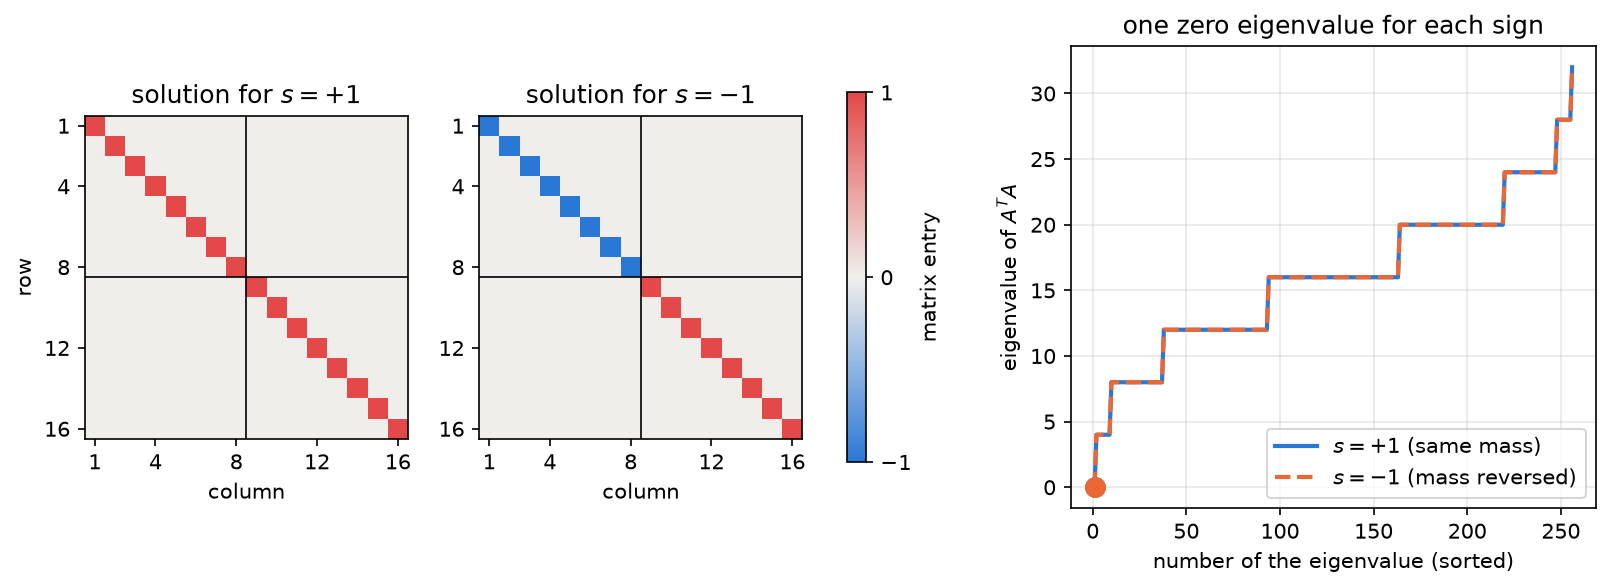

Figure 05c.1 saved as Revision/textbook/figures/05c_1_solution_spaces.png


In [4]:
from matplotlib.colors import LinearSegmentedColormap

SIGNS = LinearSegmentedColormap.from_list("signs", ["#2a78d6", "#f0efec", "#e34948"])


def heat_map(ax, matrix, title, row_label=True):
    """Draw a 16 x 16 matrix with entries from -1 to +1: blue -1, grey 0, red +1.
    Rows and columns are numbered from 1; black lines separate the two halves."""
    image = ax.imshow(matrix, cmap=SIGNS, vmin=-1, vmax=1)
    ax.set_title(title)
    ax.set_xticks([0, 3, 7, 11, 15], ["1", "4", "8", "12", "16"])
    ax.set_yticks([0, 3, 7, 11, 15], ["1", "4", "8", "12", "16"])
    ax.axhline(7.5, color="black", linewidth=0.8)
    ax.axvline(7.5, color="black", linewidth=0.8)
    ax.set_xlabel("column")
    if row_label:
        ax.set_ylabel("row")
    ax.grid(False)
    return image


eigen_same = np.linalg.eigvalsh((A_same.T @ A_same).astype(float))
eigen_reversed = np.linalg.eigvalsh((A_reversed.T @ A_reversed).astype(float))
zeros_same = int(np.sum(np.abs(eigen_same) < 1e-9))
zeros_reversed = int(np.sum(np.abs(eigen_reversed) < 1e-9))
say(f"zero eigenvalues of A^T A: s = +1: {zeros_same}; s = -1: {zeros_reversed}")
check(zeros_same == 1 and zeros_reversed == 1,
      "numerical second engine: exactly one zero eigenvalue for each sign")

fig, axes = plt.subplots(1, 3, figsize=(13.0, 4.0), width_ratios=[1, 1, 1.3])
shown_same = M_same[0] / M_same[0][0, 0]  # scaled: entry (1,1) equal to 1
shown_reversed = M_reversed[0] / M_reversed[0][0, 0] * Gamma[0, 0]  # as in Gamma
heat_map(axes[0], shown_same, "solution for $s = +1$")
image = heat_map(axes[1], shown_reversed, "solution for $s = -1$", row_label=False)
index = np.arange(1, 257)
axes[2].plot(index, eigen_same, color="#2a78d6", linewidth=2,
             label="$s = +1$ (same mass)")
axes[2].plot(index, eigen_reversed, color="#eb6834", linewidth=2, linestyle="--",
             label="$s = -1$ (mass reversed)")
axes[2].plot([1], [eigen_same[0]], "o", color="#2a78d6", markersize=9)
axes[2].plot([1], [eigen_reversed[0]], "o", color="#eb6834", markersize=9)
axes[2].set_xlabel("number of the eigenvalue (sorted)")
axes[2].set_ylabel("eigenvalue of $A^T A$")
axes[2].set_title("one zero eigenvalue for each sign")
axes[2].legend(loc="lower right")
fig.colorbar(image, ax=axes[:2], ticks=[-1, 0, 1], shrink=0.8, label="matrix entry")
save_figure(fig, "solution_spaces",
            "Left and middle: the only solutions $M$ of $M(\\gamma^a)^{\\ast} = "
            "s\\,\\gamma^a M$ for all eight gammas, as heat maps (column and row 1 "
            "to 16; blue $-1$, grey $0$, red $+1$; a solution is fixed only up to a "
            "factor, and each is drawn with the factor that makes it equal to the "
            "following): for $s = +1$ the identity matrix, for $s = -1$ the "
            "chirality $\\Gamma = \\mathrm{diag}(-1, 1)$. "
            "Right: the 256 eigenvalues of $A^T A$ for the two equation systems, "
            "sorted (horizontal axis their number, vertical axis their value); "
            "each system has exactly one zero eigenvalue (dots), so each solution "
            "space is one-dimensional.")

## 7. The two charge-conjugation matrices

From $\mathcal{C} = MC$ (section 4): $M = 1$ gives $\mathcal{C}_+ = C$ and
$M = \Gamma$ gives $\mathcal{C}_- = \Gamma C$. Their transposition rules:

- $\mathcal{C}_+^{-1}\gamma^a\mathcal{C}_+ = C\gamma^a C = -(\gamma^a)^T$ (the
  rule $C\gamma^aC^{-1} = -(\gamma^a)^T$ of the charge matrix);
- $\mathcal{C}_-^{-1}\gamma^a\mathcal{C}_- = C\Gamma\gamma^a\Gamma C =
  C(-\gamma^a)C = +(\gamma^a)^T$ (first $\Gamma\gamma^a\Gamma = -\gamma^a\Gamma
  \Gamma = -\gamma^a$, then the rule of $C$).

The next cell checks both rules, that both matrices are real, that
$\mathcal{C}_+$ is symmetric, and also that $\mathcal{C}_-$ is symmetric with
$\mathcal{C}_-\mathcal{C}_- = 1$. Then it solves, as an independent derivation, the
transposition equations $\gamma^a X = \zeta\, X(\gamma^a)^T$ for all $a$
directly: for $\zeta = -1$ the only solutions must be the multiples of $C$, for
$\zeta = +1$ those of $\Gamma C$.

In [5]:
calC_plus = M_same[0] / M_same[0][0, 0] @ C  # M = 1, so calC_+ = C
calC_minus = Gamma @ C  # M = Gamma, so calC_- = Gamma C
inverse_plus = np.linalg.inv(calC_plus)
inverse_minus = np.linalg.inv(calC_minus)
check(np.array_equal(calC_plus, C)
      and all(np.array_equal(inverse_plus @ gamma[x] @ calC_plus, -gamma[x].T)
              for x in COORDS)
      and np.array_equal(calC_plus.T, calC_plus)
      and recorded("charge_conjugation_matrix_plus"),
      "calC_+ = C: calC_+^-1 gamma^a calC_+ = -(gamma^a)^T, real and symmetric",
      record=f"{RECORD}, check charge_conjugation_matrix_plus")
check(all(np.array_equal(inverse_minus @ gamma[x] @ calC_minus, gamma[x].T)
          for x in COORDS)
      and np.isrealobj(calC_minus) and np.array_equal(calC_minus.T, calC_minus)
      and np.array_equal(calC_minus @ calC_minus, I16)
      and recorded("charge_conjugation_matrix_minus"),
      "calC_- = Gamma C: calC_-^-1 gamma^a calC_- = +(gamma^a)^T, real",
      record=f"{RECORD}, check charge_conjugation_matrix_minus")


def transposition_system(zeta):
    """Coefficient matrix of gamma^a X - zeta X (gamma^a)^T = 0 (all a)."""
    return np.vstack([np.kron(gamma[x], I16) - zeta * np.kron(I16, gamma[x])
                      for x in COORDS])


X_minus = exact_solutions(transposition_system(-1))  # should be multiples of C
X_plus = exact_solutions(transposition_system(+1))  # should be multiples of Gamma C
say(f"zeta = -1: {len(X_minus)} solution(s); zeta = +1: {len(X_plus)} solution(s)")
check(len(X_minus) == 1 and proportional(X_minus[0], C)
      and len(X_plus) == 1 and proportional(X_plus[0], Gamma @ C),
      "the only solutions of gamma^a X = -X (gamma^a)^T are multiples of C, of "
      "gamma^a X = +X (gamma^a)^T multiples of Gamma C")

PASS calC_+ = C: calC_+^-1 gamma^a calC_+ = -(gamma^a)^T, real and symmetric
     reproduces Revision/lead_checks/reports/charge-conjugation-and-u1.json, check
    charge_conjugation_matrix_plus
PASS calC_- = Gamma C: calC_-^-1 gamma^a calC_- = +(gamma^a)^T, real
     reproduces Revision/lead_checks/reports/charge-conjugation-and-u1.json, check
    charge_conjugation_matrix_minus
zeta = -1: 1 solution(s); zeta = +1: 1 solution(s)
PASS the only solutions of gamma^a X = -X (gamma^a)^T are multiples of C, of gamma^a X =
    +X (gamma^a)^T multiples of Gamma C


The next cell draws the three matrices $\mathcal{C}_+ = C$, $\Gamma$ and
$\mathcal{C}_- = \Gamma C$. Because $\Gamma = \mathrm{diag}(-1_8, 1_8)$ and $C =
\mathrm{diag}(-\sigma, \sigma)$, the product $\Gamma C = \mathrm{diag}(\sigma,
\sigma)$: multiplying by $\Gamma$ reverses the sign of the first eight rows.

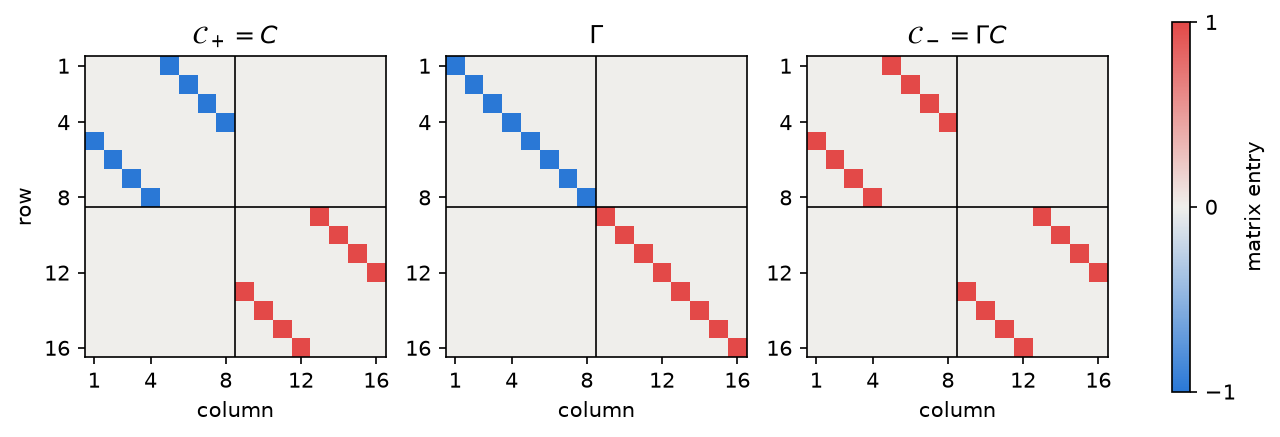

Figure 05c.2 saved as Revision/textbook/figures/05c_2_conjugation_matrices.png


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(11.0, 4.0))
heat_map(axes[0], calC_plus, r"$\mathcal{C}_+ = C$")
heat_map(axes[1], Gamma, r"$\Gamma$", row_label=False)
image = heat_map(axes[2], calC_minus, r"$\mathcal{C}_- = \Gamma C$",
                 row_label=False)
fig.colorbar(image, ax=axes, ticks=[-1, 0, 1], shrink=0.8, label="matrix entry")
save_figure(fig, "conjugation_matrices",
            "Heat maps of the two charge-conjugation matrices and of the chirality "
            "that relates them: $\\mathcal{C}_+ = C$ (left, the same-mass "
            "conjugation), $\\Gamma$ (middle) and $\\mathcal{C}_- = \\Gamma C$ "
            "(right, the mass-reversing conjugation); horizontal axis the column, "
            "vertical axis the row (1 to 16); blue $-1$, grey $0$, red $+1$. "
            "$\\Gamma C$ is $C$ with the sign of rows 1 to 8 reversed, so both of "
            "its diagonal blocks equal $+\\sigma$.")

## 8. The conjugate fields

The next cell checks the formulas of section 4 on a complex column. We take the
fixed column $\Psi_0$ with the components $(k \bmod 4) - 1 + i\,((k \bmod 3) - 1)$
for $k = 0, \dots, 15$ ($k \bmod n$ is the remainder of $k$ divided by $n$; Python
writes `%`). It computes $\bar\Psi^T = C\Psi^*$ and checks
$\mathcal{C}_+\bar\Psi^T = \Psi^*$ and $\mathcal{C}_-\bar\Psi^T = \Gamma\Psi^*$.

In [7]:
k = np.arange(16)  # 0, 1, ..., 15
PSI0 = (k % 4 - 1) + 1j * (k % 3 - 1)  # a fixed complex column with small entries
say("Psi_0 = " + ", ".join(f"{z.real:+.0f}{z.imag:+.0f}i" for z in PSI0[:8]) + ",")
say("        " + ", ".join(f"{z.real:+.0f}{z.imag:+.0f}i" for z in PSI0[8:]))
psibar_T = C @ PSI0.conj()  # (Psi^dagger C)^T = C^T Psi* = C Psi*
check(np.array_equal(calC_plus @ psibar_T, PSI0.conj())
      and np.array_equal(calC_minus @ psibar_T, Gamma @ PSI0.conj()),
      "Psi^c = calC_+ Psibar^T = Psi* and Psi^c = calC_- Psibar^T = Gamma Psi*")

Psi_0 = -1-1i, +0+0i, +1+1i, +2-1i, -1+0i, +0+1i, +1-1i, +2+0i,
        -1+1i, +0-1i, +1+0i, +2+1i, -1-1i, +0+0i, +1+1i, +2-1i
PASS Psi^c = calC_+ Psibar^T = Psi* and Psi^c = calC_- Psibar^T = Gamma Psi*


## 9. The conjugate fields solve the equation with the mass predicted

The next cell builds, with sympy and **exactly**, the solution $\Psi(x4) =
\cos(m\,x4)\Psi_0 - \sin(m\,x4)\gamma^{(x4)}\Psi_0$ for a general real mass $m$, and
its two images $\Psi^c_+ = \Psi^*$ and $\Psi^c_- = \Gamma\Psi^*$. For each of the
three fields and each mass $+m$ and $-m$ it computes the residual
$\gamma^{(x4)} d\Phi/dx4 - (\pm m)\Phi$ (which is zero exactly when $\Phi$ solves the
equation with that mass) and expands it. Prediction: $\Psi$ and $\Psi^*$ solve
with $+m$, $\Gamma\Psi^*$ with $-m$, and no field solves with both (for
$m \neq 0$).

In [8]:
x4, m = sp.symbols("x4 m", real=True)  # the time and the mass, real numbers
psi0 = sp.Matrix([sp.Integer(int(z.real)) + sp.I * sp.Integer(int(z.imag))
                  for z in PSI0])
G4 = sp.Matrix(gamma["x4"].tolist())  # gamma^(x4) as an exact sympy matrix
GAMMA = sp.Matrix(Gamma.tolist())
psi = sp.cos(m * x4) * psi0 - sp.sin(m * x4) * G4 * psi0  # the solution
fields = {"Psi": psi, "Psi* (calC_+)": psi.conjugate(),
          "Gamma Psi* (calC_-)": GAMMA * psi.conjugate()}
solves = {}  # (field, mass sign) -> True when the residual is exactly zero
for name, phi in fields.items():
    for sign in (+1, -1):
        residual = (G4 * phi.diff(x4) - sign * m * phi).applyfunc(sp.expand)
        solves[(name, sign)] = residual == sp.zeros(16, 1)
    say(f"{name:20} solves with +m: {solves[(name, 1)]!s:5}  "
        f"with -m: {solves[(name, -1)]!s:5}")
expected = {("Psi", 1): True, ("Psi", -1): False,
            ("Psi* (calC_+)", 1): True, ("Psi* (calC_+)", -1): False,
            ("Gamma Psi* (calC_-)", 1): False, ("Gamma Psi* (calC_-)", -1): True}
check(solves == expected,
      "exactly: Psi and Psi* solve with +m, Gamma Psi* solves with -m")

Psi                  solves with +m: True   with -m: False
Psi* (calC_+)        solves with +m: True   with -m: False
Gamma Psi* (calC_-)  solves with +m: False  with -m: True
PASS exactly: Psi and Psi* solve with +m, Gamma Psi* solves with -m


The next cell evaluates the three fields numerically for $m = 1$ (so $x4$ is
measured in units of $1/m$) on 801 points from $x4 = 0$ to $4\pi$, and the largest
size of each residual on these points. `np.einsum("rc,tc->tr", G, F)` multiplies the
matrix $G$ with the column of $F$ at every time point $t$ at once. It then draws the
first component of each field (real and imaginary part) and a table of the largest
residuals.

In [9]:
t = np.linspace(0.0, 4.0 * np.pi, 801)  # the time x4 in units of 1/m, m = 1
g4 = gamma["x4"].astype(float)
cos_t, sin_t = np.cos(t)[:, None], np.sin(t)[:, None]  # columns for broadcasting
psi_t = cos_t * PSI0 - sin_t * np.einsum("rc,c->r", g4, PSI0)  # row t: Psi(x4_t)
dpsi_t = -sin_t * PSI0 - cos_t * np.einsum("rc,c->r", g4, PSI0)  # dPsi/dx4
numeric = {"Psi": (psi_t, dpsi_t),
           "Psi* (calC_+)": (psi_t.conj(), dpsi_t.conj()),
           "Gamma Psi* (calC_-)": (psi_t.conj() @ Gamma.T, dpsi_t.conj() @ Gamma.T)}
largest = {}  # (field, sign) -> largest size of the residual over the 801 points
for name, (phi, dphi) in numeric.items():
    for sign in (+1, -1):
        residual = np.einsum("rc,tc->tr", g4, dphi) - sign * 1.0 * phi
        largest[(name, sign)] = float(np.max(np.linalg.norm(residual, axis=1)))
    shown = {sign: (f"{largest[(name, sign)]:.2f}" if largest[(name, sign)] > 1e-12
                    else "below 1e-12") for sign in (1, -1)}  # rounding-proof text
    say(f"{name:20} largest residual with +m: {shown[1]:11}, with -m: {shown[-1]}")
check(all((largest[key] < 1e-12) == solves[key] for key in solves),
      "the numerical residuals agree with the exact result")

Psi                  largest residual with +m: below 1e-12, with -m: 11.83
Psi* (calC_+)        largest residual with +m: below 1e-12, with -m: 11.83
Gamma Psi* (calC_-)  largest residual with +m: 11.83      , with -m: below 1e-12
PASS the numerical residuals agree with the exact result


The next cell draws the first component of the three fields along $x4$: $\Psi^*$
has the same real part as $\Psi$ and the opposite imaginary part; $\Gamma\Psi^*$
has, in the first half (components 1 to 8, where $\Gamma = -1$), the opposite sign
of $\Psi^*$.

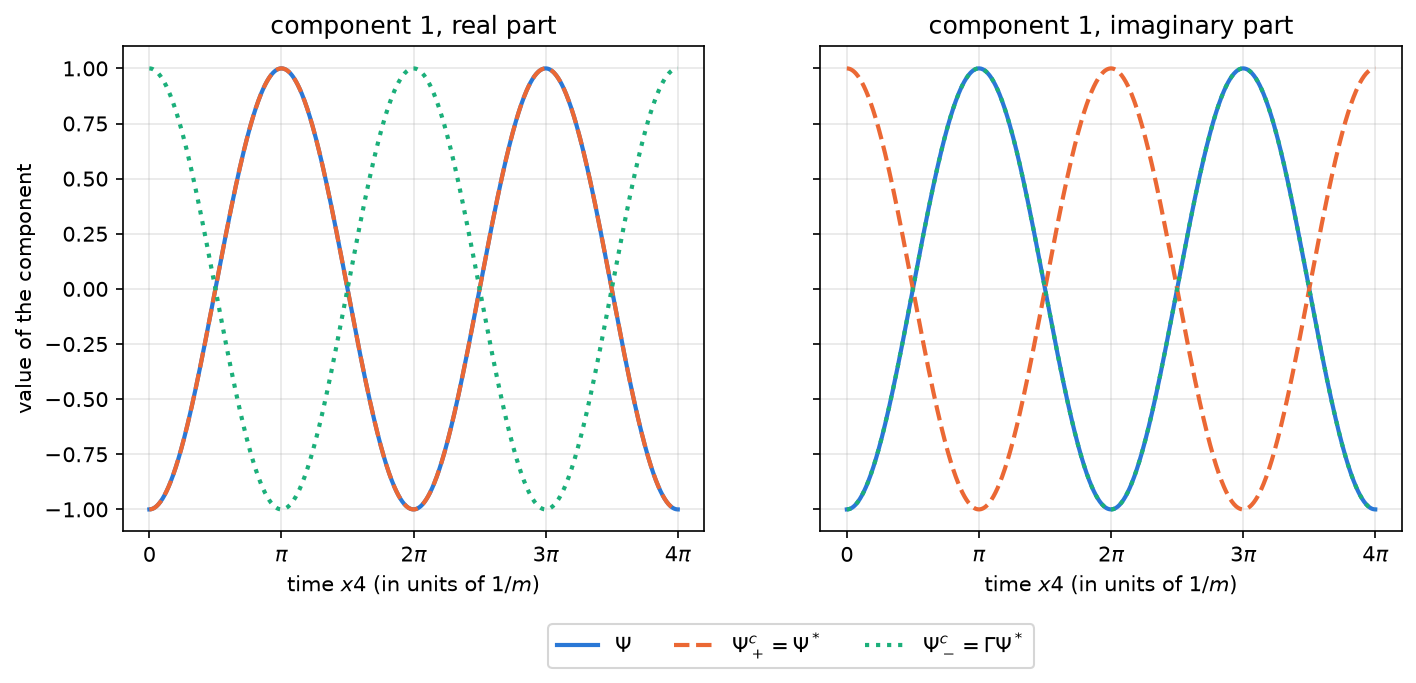

Figure 05c.3 saved as Revision/textbook/figures/05c_3_conjugate_solutions.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.2), sharey=True)
styles = {"Psi": ("#2a78d6", "-"), "Psi* (calC_+)": ("#eb6834", "--"),
          "Gamma Psi* (calC_-)": ("#1baf7a", ":")}
labels = {"Psi": r"$\Psi$", "Psi* (calC_+)": r"$\Psi^c_+ = \Psi^*$",
          "Gamma Psi* (calC_-)": r"$\Psi^c_- = \Gamma\Psi^*$"}
for name, (phi, _) in numeric.items():
    color, line = styles[name]
    axes[0].plot(t, phi[:, 0].real, color=color, linestyle=line, linewidth=2,
                 label=labels[name])
    axes[1].plot(t, phi[:, 0].imag, color=color, linestyle=line, linewidth=2,
                 label=labels[name])
for ax, part in zip(axes, ["real part", "imaginary part"]):
    ax.set_xticks([0, np.pi, 2 * np.pi, 3 * np.pi, 4 * np.pi],
                  ["0", r"$\pi$", r"$2\pi$", r"$3\pi$", r"$4\pi$"])
    ax.set_xlabel("time $x4$ (in units of $1/m$)")
    ax.set_title(f"component 1, {part}")
axes[0].set_ylabel("value of the component")
axes[1].legend(loc="upper center", bbox_to_anchor=(-0.05, -0.17), ncol=3)
save_figure(fig, "conjugate_solutions",
            "The first of the 16 components of the solution $\\Psi(x4) = "
            "\\cos(m x4)\\Psi_0 - \\sin(m x4)\\gamma^{(x4)}\\Psi_0$ of the free "
            "equation (solid) and of its two charge conjugates $\\Psi^{\\ast} = "
            "\\mathcal{C}_+\\bar\\Psi^T$ (dashed) and $\\Gamma\\Psi^{\\ast} = "
            "\\mathcal{C}_-\\bar\\Psi^T$ (dotted), real part left and imaginary "
            "part right; horizontal axis the time $x4$ in units of $1/m$, "
            "vertical axis the value (a pure number). $\\Psi^{\\ast}$ flips the sign "
            "of the imaginary part; $\\Gamma\\Psi^{\\ast}$ in addition flips the sign "
            "of every component of the first half, here component 1, so its real "
            "part is the mirror image of that of $\\Psi$ and its imaginary part lies "
            "exactly on that of $\\Psi$ (right, dotted on solid).")

The next cell draws the table of the largest residuals: a residual of zero (up to
the rounding of floating-point numbers, below $10^{-12}$) means that the field
solves the equation with that mass.

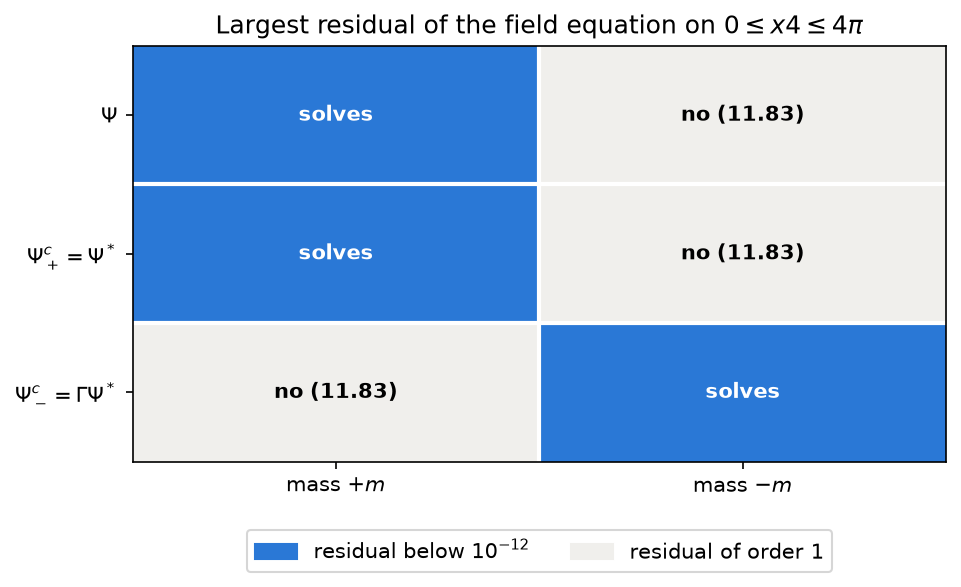

Figure 05c.4 saved as Revision/textbook/figures/05c_4_which_mass.png


In [11]:
from matplotlib.patches import Patch  # a coloured square for a legend

names = list(numeric)
table = np.array([[largest[(name, 1)], largest[(name, -1)]] for name in names])
fig, ax = plt.subplots(figsize=(7.0, 3.6))
solved = table < 1e-12  # True where the field solves the equation
ax.imshow(np.where(solved, 1.0, 0.0), cmap=LinearSegmentedColormap.from_list(
    "solve", ["#f0efec", "#2a78d6"]), vmin=0, vmax=1, aspect="auto")
for r in range(3):
    for c in range(2):
        text = "solves" if solved[r, c] else f"no ({table[r, c]:.2f})"
        ax.text(c, r, text, ha="center", va="center",
                color="white" if solved[r, c] else "black", fontweight="bold")
ax.axhline(0.5, color="white", linewidth=2)
ax.axhline(1.5, color="white", linewidth=2)
ax.axvline(0.5, color="white", linewidth=2)
ax.set_xticks([0, 1], ["mass $+m$", "mass $-m$"])
ax.set_yticks(range(3), [labels[name] for name in names])
ax.set_title("Largest residual of the field equation on $0 \\leq x4 \\leq 4\\pi$")
ax.legend(handles=[Patch(color="#2a78d6", label="residual below $10^{-12}$"),
                   Patch(color="#f0efec", label="residual of order 1")],
          loc="upper center", bbox_to_anchor=(0.5, -0.14), ncol=2)
ax.grid(False)
save_figure(fig, "which_mass",
            "Which mass each field solves the free equation with: rows the "
            "solution $\\Psi$ and its two charge conjugates $\\Psi^{\\ast}$ and "
            "$\\Gamma\\Psi^{\\ast}$, columns the masses $+m$ and $-m$; "
            "each square gives "
            "the largest size of the residual $\\gamma^{(x4)} d\\Phi/dx4 \\mp "
            "m\\Phi$ on 801 points with $m = 1$ (blue: zero up to rounding, the "
            "field solves; grey: the residual, the field does not solve). "
            "$\\mathcal{C}_+$ keeps the mass, $\\mathcal{C}_-$ reverses it, as "
            "the exact computation proves.")

## 10. The scalar S and the charge density J for commuting components

For commuting components (the field dirac16complex00) the next cell computes,
along the solution, the scalar $S = \Psi^\dagger C\Psi$ and the charge density
$J^{(x4)} = \Psi^\dagger B\Psi$ of the three fields at all 801 time points. Both
are constant along $x4$ (the derivative of $S$ is $-m\Psi^\dagger(
(\gamma^{(x4)})^TC + C\gamma^{(x4)})\Psi = 0$, because $(\gamma^{(x4)})^T =
-\gamma^{(x4)}$ commutes with $C$; $J^{(x4)}$ is the conserved charge density). The
prediction of the Revision record for commuting components: $\Psi^*$ keeps $S$ and
reverses $J$; $\Gamma\Psi^*$ keeps $S$ and keeps $J$.

In [12]:
bilinears = {}  # field -> (S at every time point, J^(x4) at every time point)
for name, (phi, _) in numeric.items():
    S_t = np.einsum("tr,rc,tc->t", phi.conj(), C, phi).real  # Psi^dagger C Psi
    J_t = np.einsum("tr,rc,tc->t", phi.conj(), B, phi).real  # Psi^dagger B Psi
    bilinears[name] = (S_t, J_t)
    say(f"{name:20} S from {S_t.min():+.6f} to {S_t.max():+.6f}; "
        f"J^(x4) from {J_t.min():+.6f} to {J_t.max():+.6f}")
S_psi, J_psi = bilinears["Psi"][0][0], bilinears["Psi"][1][0]
report("S of the solution Psi", f"{S_psi:+.6f}")
report("J^(x4) of the solution Psi", f"{J_psi:+.6f}")
constant = all(np.ptp(v) < 1e-12 for pair in bilinears.values() for v in pair)
check(constant and abs(S_psi) > 1 and abs(J_psi) > 1
      and np.allclose(bilinears["Psi* (calC_+)"][0], S_psi)
      and np.allclose(bilinears["Psi* (calC_+)"][1], -J_psi)
      and np.allclose(bilinears["Gamma Psi* (calC_-)"][0], S_psi)
      and np.allclose(bilinears["Gamma Psi* (calC_-)"][1], J_psi),
      "commuting components: Psi* keeps S and reverses J; Gamma Psi* keeps S and J")

Psi                  S from -2.000000 to -2.000000; J^(x4) from -6.000000 to -6.000000
Psi* (calC_+)        S from -2.000000 to -2.000000; J^(x4) from +6.000000 to +6.000000
Gamma Psi* (calC_-)  S from -2.000000 to -2.000000; J^(x4) from -6.000000 to -6.000000
RESULT S of the solution Psi = -2.000000
RESULT J^(x4) of the solution Psi = -6.000000
PASS commuting components: Psi* keeps S and reverses J; Gamma Psi* keeps S and J


The next cell draws these constant values as bars: one group for $S$, one for
$J^{(x4)}$.

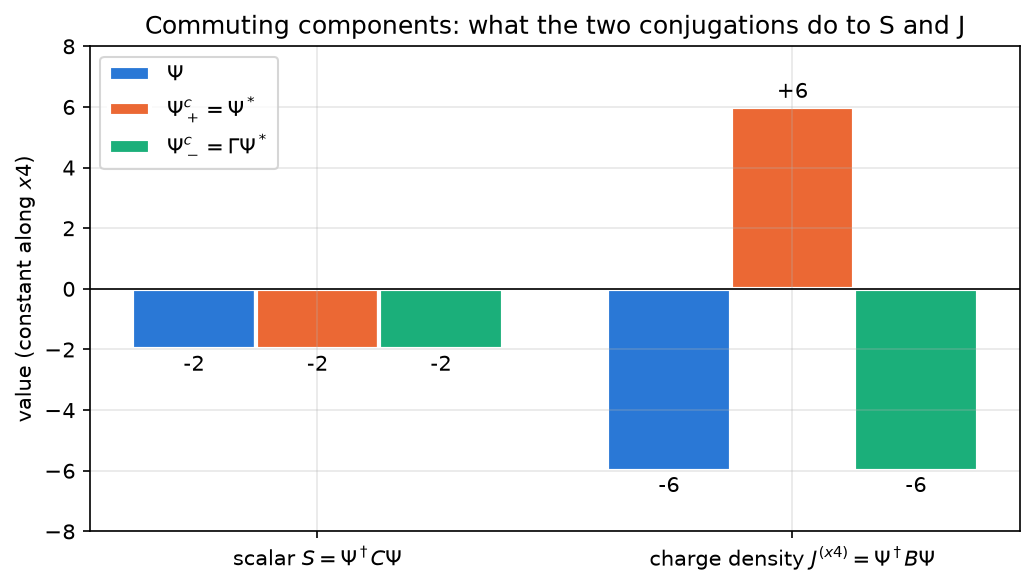

Figure 05c.5 saved as Revision/textbook/figures/05c_5_bilinears.png


In [13]:
fig, ax = plt.subplots(figsize=(8.0, 4.2))
width = 0.26  # the width of one bar
for j, name in enumerate(names):
    color, _ = styles[name]
    values = [bilinears[name][0][0], bilinears[name][1][0]]
    bars = ax.bar(np.arange(2) + (j - 1) * width, values, width, color=color,
                  edgecolor="white", linewidth=2, label=labels[name])
    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, v + (0.3 if v > 0 else -0.7),
                f"{v:+.0f}", ha="center")
ax.axhline(0.0, color="black", linewidth=0.8)
ax.set_xticks([0, 1], [r"scalar $S = \Psi^\dagger C\Psi$",
                       r"charge density $J^{(x4)} = \Psi^\dagger B\Psi$"])
ax.set_ylabel("value (constant along $x4$)")
ax.set_ylim(-8, 8)
ax.set_title("Commuting components: what the two conjugations do to S and J")
ax.legend(loc="upper left")
save_figure(fig, "bilinears",
            "The scalar $S$ (left group) and the charge density $J^{(x4)}$ (right "
            "group) of the solution $\\Psi$ (blue) and of its charge conjugates "
            "$\\Psi^{\\ast}$ (orange) and $\\Gamma\\Psi^{\\ast}$ (aqua), for commuting "
            "components; vertical axis the value, which is the same at every time "
            "$x4$. All three have the same $S = -2$; $\\Psi^{\\ast}$ has the opposite "
            "charge density $+6$, $\\Gamma\\Psi^{\\ast}$ the same $-6$: for commuting "
            "components $\\mathcal{C}_+$ reverses the charge and keeps the mass, "
            "$\\mathcal{C}_-$ keeps the charge and reverses the mass.")

## 11. The sign table for commuting and anticommuting components

For a bilinear $\Psi^\dagger K\Psi = \sum_{r,c}\Psi_r^* K_{rc}\Psi_c$ and the map
$\Psi \to M\Psi^*$ with a real $M$, line by line:

1. $(M\Psi^*)^\dagger = \Psi^T M^\dagger$ (the conjugate of $\Psi^*$ is $\Psi$), so
   the bilinear becomes $\Psi^T M^\dagger K M\Psi^* = \sum_{r,c}\Psi_r\,
   (M^\dagger KM)_{rc}\,\Psi_c^*$.
2. Exchange the two factors $\Psi_r$ and $\Psi_c^*$; this costs the sign
   $\epsilon$: $\sum_{r,c}\epsilon\,\Psi_c^*(M^\dagger KM)_{rc}\Psi_r$.
3. Rename $r \leftrightarrow c$: this is $\Psi^\dagger K'\Psi$ with
   $K' = \epsilon\,(M^\dagger KM)^T$.

So the bilinear with matrix $K$ turns into the bilinear with matrix $K'$. The next
cell computes $K'$ for $K = C$ (the scalar $S$) and $K = -iC\gamma^a$ (the eight
currents $J^a$), for $M = 1$ ($\mathcal{C}_+$) and $M = \Gamma$ ($\mathcal{C}_-$)
and $\epsilon = \pm1$, and records the sign with $K' = \pm K$. It compares the
table with the signs that the Revision record measured (stored in its detail text
after the word measured). The record adds: in the quantum theory normal ordering
supplies one more sign for each anticommuting bilinear, which gives the standard
$(S, J) \to (S, -J)$ for $\mathcal{C}_+$.

In [14]:
K_S = C.astype(complex)  # the matrix of the scalar S
K_J = [-1j * (C @ gamma[x]) for x in COORDS]  # the matrices of the currents J^a


def sign_of(M, K, eps):
    """+1 if eps (M^dagger K M)^T = K, -1 if it equals -K, 0 otherwise."""
    new = eps * (M.conj().T @ K @ M).T
    return 1 if np.array_equal(new, K) else (-1 if np.array_equal(new, -K) else 0)


measured = {}  # the record's keys, e.g. "plus,eps=1" -> [sign of S, [signs of J]]
for map_name, M in (("plus", I16), ("minus", Gamma)):
    for eps in (1, -1):
        measured[f"{map_name},eps={eps}"] = [
            sign_of(M, K_S, eps), [sign_of(M, K, eps) for K in K_J]]
for key, (sign_S, signs_J) in measured.items():
    say(f"{key:13} S -> {sign_S:+d} S;  J^a -> s J^a with s = "
        + " ".join(f"{s:+d}" for s in signs_J))
recorded_table = json.loads(detail("bilinears_under_charge_conjugation")
                            .split("measured: ", 1)[1])
check(measured == recorded_table and recorded("bilinears_under_charge_conjugation"),
      "the signs of S and J under calC_+ and calC_-, commuting and anticommuting, "
      "equal the recorded table",
      record=f"{RECORD}, check bilinears_under_charge_conjugation")

plus,eps=1    S -> +1 S;  J^a -> s J^a with s = -1 -1 -1 -1 -1 -1 -1 -1
plus,eps=-1   S -> -1 S;  J^a -> s J^a with s = +1 +1 +1 +1 +1 +1 +1 +1
minus,eps=1   S -> +1 S;  J^a -> s J^a with s = +1 +1 +1 +1 +1 +1 +1 +1
minus,eps=-1  S -> -1 S;  J^a -> s J^a with s = -1 -1 -1 -1 -1 -1 -1 -1
PASS the signs of S and J under calC_+ and calC_-, commuting and anticommuting, equal the
    recorded table
     reproduces Revision/lead_checks/reports/charge-conjugation-and-u1.json, check
    bilinears_under_charge_conjugation


The next cell draws the sign table: four rows (two maps, two kinds of components),
nine columns ($S$ and the eight currents).

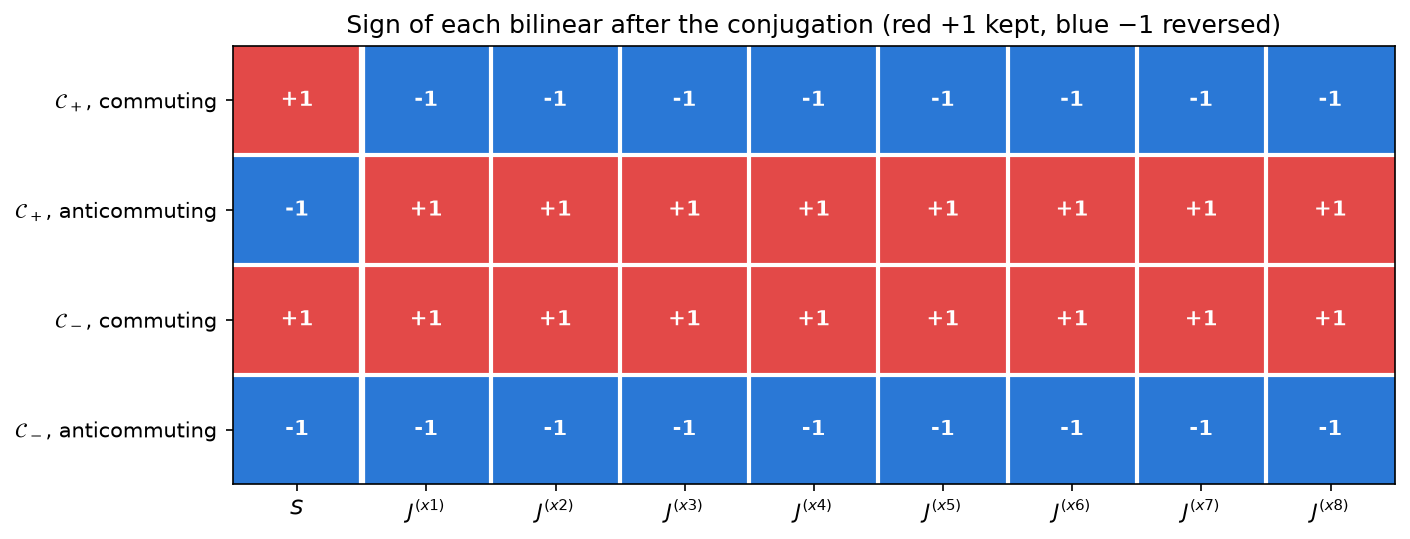

Figure 05c.6 saved as Revision/textbook/figures/05c_6_sign_table.png


In [15]:
row_keys = ["plus,eps=1", "plus,eps=-1", "minus,eps=1", "minus,eps=-1"]
row_names = [r"$\mathcal{C}_+$, commuting", r"$\mathcal{C}_+$, anticommuting",
             r"$\mathcal{C}_-$, commuting", r"$\mathcal{C}_-$, anticommuting"]
grid = np.array([[measured[key][0]] + measured[key][1] for key in row_keys])
fig, ax = plt.subplots(figsize=(10.0, 3.8))
ax.imshow(grid, cmap=SIGNS, vmin=-1, vmax=1, aspect="auto")
for r in range(4):
    for c in range(9):
        ax.text(c, r, f"{grid[r, c]:+d}", ha="center", va="center", color="white",
                fontweight="bold")
for k in range(1, 4):
    ax.axhline(k - 0.5, color="white", linewidth=2)
for k in range(1, 9):
    ax.axvline(k - 0.5, color="white", linewidth=3 if k == 1 else 2)
ax.set_xticks(range(9), ["$S$"] + [rf"$J^{{({x})}}$" for x in COORDS])
ax.set_yticks(range(4), row_names)
ax.set_title("Sign of each bilinear after the conjugation (red $+1$ kept, blue "
             "$-1$ reversed)")
ax.grid(False)
save_figure(fig, "sign_table",
            "The sign that each bilinear acquires under the two charge "
            "conjugations, for commuting and for anticommuting (classical "
            "Grassmann) components: columns the scalar $S$ and the eight currents "
            "$J^a$, rows the map and the kind of component; red $+1$ the bilinear "
            "is kept, blue $-1$ it is reversed. $\\mathcal{C}_+$ on commuting "
            "components keeps $S$ and reverses every current; $\\mathcal{C}_-$ on "
            "commuting components keeps both; for anticommuting components every "
            "sign is flipped once more by the exchange of two factors (normal "
            "ordering in the quantum theory flips it back).")

## 12. The reality (Majorana) conditions

A field equal to its own conjugate, $\Psi = M\Psi^*$, is possible without forcing
$\Psi = 0$ only if applying the condition twice gives back $\Psi$: $\Psi = M(M
\Psi^*)^* = MM^*\Psi$, so $MM^* = 1$ is needed. The next cell checks $MM^* = 1$ for
$M = 1$ (the condition $\Psi = \Psi^*$: a real field) and for $M = \Gamma$ (the
condition $\Psi = \Gamma\Psi^*$: the first half imaginary, the second half real).

In [16]:
check(np.array_equal(I16 @ np.conj(I16), I16)
      and np.array_equal(Gamma @ np.conj(Gamma), I16)
      and recorded("majorana_conditions_consistent"),
      "M M* = 1 for M = 1 and M = Gamma: both reality conditions are consistent",
      record=f"{RECORD}, check majorana_conditions_consistent")

PASS M M* = 1 for M = 1 and M = Gamma: both reality conditions are consistent
     reproduces Revision/lead_checks/reports/charge-conjugation-and-u1.json, check
    majorana_conditions_consistent


Consistency is a statement about one moment. Is the condition kept as the field
evolves? For the solution $\Psi(x4)$ of section 9 with a starting column that obeys
the condition:

- start real ($\Psi_0^* = \Psi_0$): all factors of the solution are real, so
  $\Psi(x4)$ stays real at all times;
- start with $\Psi_0 = \Gamma\Psi_0^*$: then $\Gamma\Psi(x4)^* = \cos(m x4)\Gamma
  \Psi_0^* - \sin(m x4)\Gamma\gamma^{(x4)}\Psi_0^* = \cos(m x4)\Psi_0 + \sin(m x4)
  \gamma^{(x4)}\Psi_0$ (because $\Gamma\gamma^{(x4)} = -\gamma^{(x4)}\Gamma$), so
  $\Psi(x4) - \Gamma\Psi(x4)^* = -2\sin(m x4)\gamma^{(x4)}\Psi_0$, whose size is
  $2|\sin(m x4)|\,|\Psi_0|$ ($\gamma^{(x4)}$ is a signed permutation and keeps
  sizes).

So the second condition holds at all times only for $m = 0$. This is what
"mass reversed" means: a field equal to its $\mathcal{C}_-$ image would have to
solve the equation with $V$ and with $-V$ at once. The next cell computes both
violations for $m = 1$, $m = 0.5$ and $m = 0$ and draws them.

PASS the two starting columns obey Psi_0 = Gamma Psi_0* and Psi_0 = Psi_0*
PASS Psi = Psi* is kept in time; Psi = Gamma Psi* is violated by 2 |sin(m x4)|


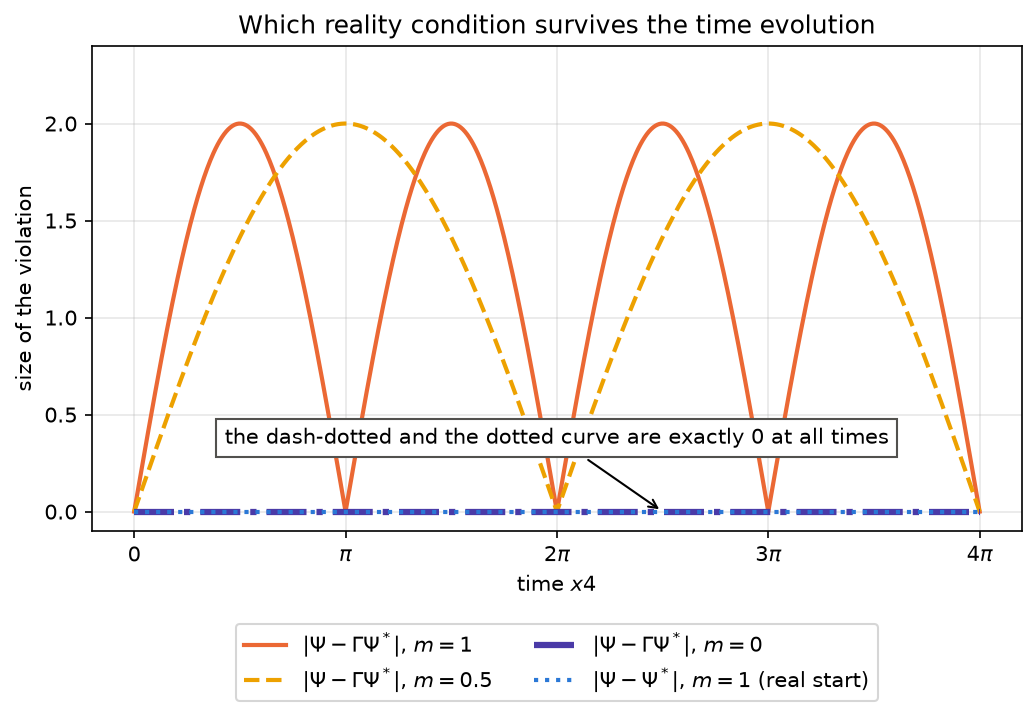

Figure 05c.7 saved as Revision/textbook/figures/05c_7_reality_in_time.png


In [17]:
start_real = PSI0.real.astype(complex)  # obeys Psi_0* = Psi_0
start_gamma = np.concatenate([1j * PSI0.imag[:8], PSI0.real[8:]])  # first half
start_gamma = start_gamma / np.linalg.norm(start_gamma)  # imaginary, size 1
start_real = start_real / np.linalg.norm(start_real)  # size 1
check(np.allclose(start_gamma, Gamma @ start_gamma.conj())
      and np.allclose(start_real, start_real.conj()),
      "the two starting columns obey Psi_0 = Gamma Psi_0* and Psi_0 = Psi_0*")


def evolve(start, mass):
    """The solution cos(m x4) start - sin(m x4) gamma^(x4) start at all times t."""
    return (np.cos(mass * t)[:, None] * start
            - np.sin(mass * t)[:, None] * np.einsum("rc,c->r", g4, start))


violation = {}  # (condition, mass) -> size of the violation at every time
for mass in (1.0, 0.5, 0.0):
    f_real = evolve(start_real, mass)
    f_gamma = evolve(start_gamma, mass)
    violation[("real", mass)] = np.linalg.norm(f_real - f_real.conj(), axis=1)
    violation[("gamma", mass)] = np.linalg.norm(f_gamma - f_gamma.conj() @ Gamma.T,
                                                axis=1)
check(all(np.max(violation[("real", mass)]) < 1e-12 for mass in (1.0, 0.5, 0.0))
      and np.max(violation[("gamma", 0.0)]) < 1e-12
      and np.allclose(violation[("gamma", 1.0)], 2 * np.abs(np.sin(t)))
      and np.allclose(violation[("gamma", 0.5)], 2 * np.abs(np.sin(0.5 * t))),
      "Psi = Psi* is kept in time; Psi = Gamma Psi* is violated by 2 |sin(m x4)|")
fig, ax = plt.subplots(figsize=(8.0, 4.2))
ax.plot(t, violation[("gamma", 1.0)], color="#eb6834", linewidth=2,
        label=r"$|\Psi - \Gamma\Psi^*|$, $m = 1$")
ax.plot(t, violation[("gamma", 0.5)], color="#eda100", linewidth=2, linestyle="--",
        label=r"$|\Psi - \Gamma\Psi^*|$, $m = 0.5$")
ax.plot(t, violation[("gamma", 0.0)], color="#4a3aa7", linewidth=3, linestyle="-.",
        label=r"$|\Psi - \Gamma\Psi^*|$, $m = 0$")
ax.plot(t, violation[("real", 1.0)], color="#2a78d6", linewidth=2, linestyle=":",
        label=r"$|\Psi - \Psi^*|$, $m = 1$ (real start)")
ax.set_xticks([0, np.pi, 2 * np.pi, 3 * np.pi, 4 * np.pi],
              ["0", r"$\pi$", r"$2\pi$", r"$3\pi$", r"$4\pi$"])
ax.set_xlabel("time $x4$")
ax.set_ylabel("size of the violation")
ax.set_ylim(-0.1, 2.4)
ax.annotate("the dash-dotted and the dotted curve are exactly 0 at all times",
            (2.5 * np.pi, 0.0), xytext=(2.0 * np.pi, 0.35), ha="center",
            arrowprops={"arrowstyle": "->", "color": "black"},
            bbox={"facecolor": "white", "edgecolor": "#52514e"})
ax.set_title("Which reality condition survives the time evolution")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.17), ncol=2)
save_figure(fig, "reality_in_time",
            "How far the free solution moves away from the two reality "
            "conditions, for starting columns of size 1 that obey them: the size "
            "of $\\Psi - \\Gamma\\Psi^{\\ast}$ for the masses $m = 1$ (solid), "
            "$m = 0.5$ (dashed) and $m = 0$ (dash-dotted, zero), and the size of "
            "$\\Psi - \\Psi^{\\ast}$ for a real start (dotted, zero); horizontal "
            "axis the time $x4$, vertical axis the size (a pure number). "
            "The real field "
            "stays real; the condition $\\Psi = \\Gamma\\Psi^{\\ast}$ of the "
            "mass-reversing conjugation is violated by $2|\\sin(m x4)|$ unless "
            "$m = 0$.")

## 13. Real fields

For a **real** commuting field ($\Psi^* = \Psi$):

- the currents vanish identically: $J^a = -i\Psi^TC\gamma^a\Psi = 0$, because
  $C\gamma^a$ is antisymmetric and $u^TAu = 0$ for every antisymmetric $A$ (the
  terms $u_rA_{rc}u_c$ and $u_cA_{cr}u_r$ cancel); a real field carries no U(1)
  charge;
- $\mathcal{C}_+$ acts as the identity: $\Psi^c_+ = \Psi^* = \Psi$ (a real field is
  its own conjugate);
- the **real matrix** $\Gamma$ maps real fields to real fields, keeps $S$
  ($\Gamma^TC\Gamma = C$) and reverses every kinetic matrix ($\Gamma^TC\gamma^a\Gamma
  = -C\gamma^a$): with $(m, \lambda) \to (-m, -\lambda)$ it maps solutions to
  solutions (the pairing theorem T1 of the Revision record).

The next cell checks the first statement with sympy for 16 real symbols $r_1, \dots,
r_{16}$ (all real columns at once), and the third one with exact matrices and on
the real solution $\Psi(x4)$ that starts at the real part of $\Psi_0$: $\Gamma\Psi$
solves the equation with $-m$.

In [18]:
r = sp.Matrix(sp.symbols("r1:17", real=True))  # a general real column
currents = [sp.expand((-sp.I * r.T * sp.Matrix((C @ gamma[x]).tolist()) * r)[0, 0])
            for x in COORDS]
say("J^a of a general real column, a = x1..x8: " + ", ".join(map(str, currents)))
S_change = sp.expand((GAMMA * r).T * sp.Matrix(C.tolist()) * (GAMMA * r)
                     - r.T * sp.Matrix(C.tolist()) * r)[0, 0]
kinetic_reversed = all(np.array_equal(Gamma.T @ C @ gamma[x] @ Gamma,
                                      -(C @ gamma[x])) for x in COORDS)
psi0_real = psi0.applyfunc(sp.re)  # the real part of every component of Psi_0
psi_real = sp.cos(m * x4) * psi0_real - sp.sin(m * x4) * G4 * psi0_real
image = GAMMA * psi_real  # the real field Gamma Psi
image_solves_minus = (G4 * image.diff(x4) + m * image).applyfunc(sp.expand) \
    == sp.zeros(16, 1)
check(all(c == 0 for c in currents) and S_change == 0 and kinetic_reversed
      and psi_real.conjugate() == psi_real and image_solves_minus
      and recorded("real_fields_charge_conjugation"),
      "real fields: J = 0, calC_+ is the identity, Gamma keeps S, reverses the "
      "kinetic matrices and maps a solution with m to one with -m",
      record=f"{RECORD}, check real_fields_charge_conjugation")

J^a of a general real column, a = x1..x8: 0, 0, 0, 0, 0, 0, 0, 0
PASS real fields: J = 0, calC_+ is the identity, Gamma keeps S, reverses the kinetic
    matrices and maps a solution with m to one with -m
     reproduces Revision/lead_checks/reports/charge-conjugation-and-u1.json, check
    real_fields_charge_conjugation


The next cell draws the real solution, its $\mathcal{C}_+$ image (identical) and its
$\Gamma$ image, for one component of each half: component 1 changes sign under
$\Gamma$, component 9 does not.

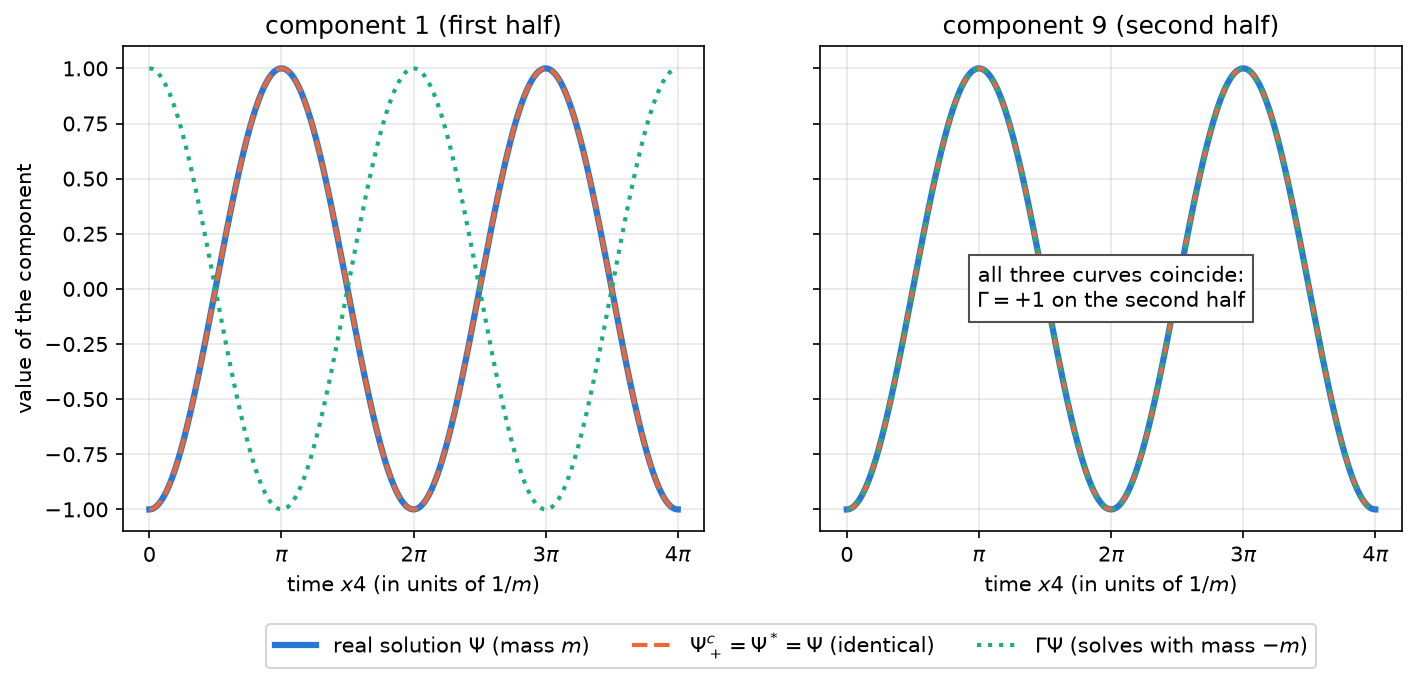

Figure 05c.8 saved as Revision/textbook/figures/05c_8_real_field.png


In [19]:
real_t = evolve(PSI0.real.astype(complex), 1.0).real  # the real solution, m = 1
gamma_t = real_t @ Gamma.T  # Gamma Psi at every time
fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.2), sharey=True)
for ax, comp in zip(axes, [0, 8]):
    ax.plot(t, real_t[:, comp], color="#2a78d6", linewidth=3,
            label=r"real solution $\Psi$ (mass $m$)")
    ax.plot(t, real_t[:, comp], color="#eb6834", linewidth=2, linestyle="--",
            label=r"$\Psi^c_+ = \Psi^* = \Psi$ (identical)")
    ax.plot(t, gamma_t[:, comp], color="#1baf7a", linewidth=2, linestyle=":",
            label=r"$\Gamma\Psi$ (solves with mass $-m$)")
    ax.set_xticks([0, np.pi, 2 * np.pi, 3 * np.pi, 4 * np.pi],
                  ["0", r"$\pi$", r"$2\pi$", r"$3\pi$", r"$4\pi$"])
    ax.set_xlabel("time $x4$ (in units of $1/m$)")
    half = "first" if comp < 8 else "second"  # components 1-8 or 9-16
    ax.set_title(f"component {comp + 1} ({half} half)")
axes[0].set_ylabel("value of the component")
axes[1].text(2.0 * np.pi, 0.0, "all three curves coincide:\n"
             r"$\Gamma = +1$ on the second half", ha="center", va="center",
             bbox={"facecolor": "white", "edgecolor": "#52514e"})
axes[1].legend(loc="upper center", bbox_to_anchor=(-0.05, -0.17), ncol=3)
save_figure(fig, "real_field",
            "A real solution of the free equation (solid), its same-mass "
            "conjugate $\\Psi^{\\ast} = \\mathcal{C}_+\\bar\\Psi^T$ (dashed, lying "
            "exactly on the solid line) and its image $\\Gamma\\Psi$ under the real "
            "chirality matrix (dotted), for component 1 (left, first half) and "
            "component 9 (right, second half); horizontal axis the time $x4$ in "
            "units of $1/m$, vertical axis the value. For a real field the "
            "same-mass conjugation does nothing; the nontrivial real map is "
            "$\\Gamma$, which flips the first half and solves the equation with the "
            "mass reversed.")

## 14. The quantised field

After quantisation, the components of dirac16complex are operators with
$\{\Psi_r, \Psi_c^\dagger\} = B_{rc}\,\delta$. Consider the map $\Psi \to
M\Psi^{\dagger T}$ (the operator form of $M\Psi^*$) with a real $M$. Its adjoint
is $\Psi^\dagger \to (M\Psi^{\dagger T})^\dagger = \Psi^TM^\dagger$. The
anticommutator of the new operators is then $M\{\Psi^{\dagger T}, \Psi^T\}
M^\dagger = M B^T M^\dagger\,\delta$ (the anticommutator of $\Psi_c^\dagger$ with
$\Psi_r$ is $B_{rc}$, which is the entry $(c, r)$ of $B^T$). The rule is preserved
exactly when $MB^TM^\dagger = B$. The next cell checks the recorded result: it holds
for $M = \Gamma$ and fails for $M = 1$, where it gives $-B$ (because $B^T = -B$).

B^T = -B: True;  1 B^T 1 = B: False;  Gamma B^T Gamma^dagger = B: True
PASS M B^T M^dagger = B for M = Gamma and = -B for M = 1: the conjugation of the
    quantised field is Psi -> Gamma Psi^(dagger T), which reverses the mass
     reproduces Revision/lead_checks/reports/charge-conjugation-and-u1.json, check
    quantum_charge_conjugation_unitary_type


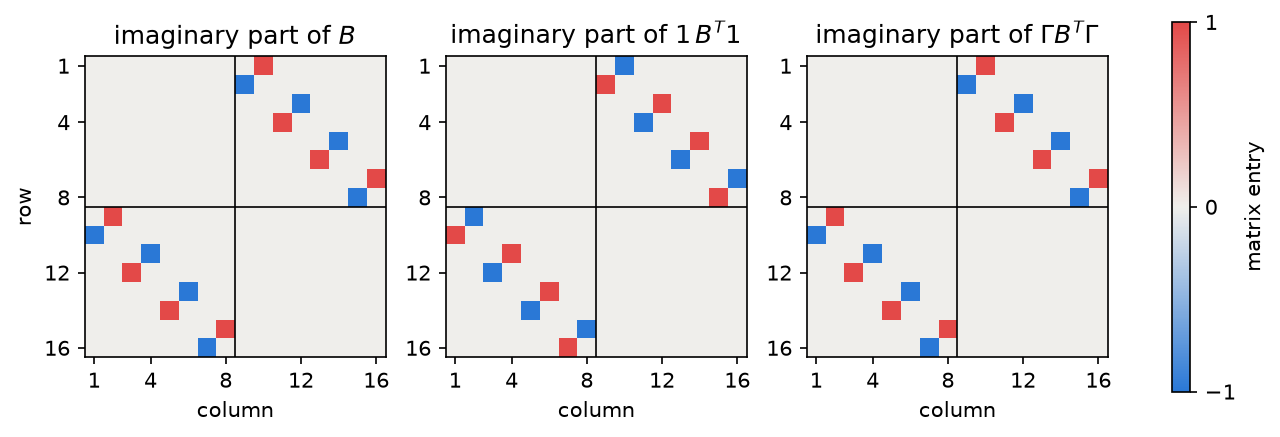

Figure 05c.9 saved as Revision/textbook/figures/05c_9_quantum_b.png


In [20]:
q_plus = I16 @ B.T @ I16.conj().T  # M = 1
q_minus = Gamma @ B.T @ Gamma.conj().T  # M = Gamma
say(f"B^T = -B: {np.array_equal(B.T, -B)};  1 B^T 1 = B: "
    f"{np.array_equal(q_plus, B)};  Gamma B^T Gamma^dagger = B: "
    f"{np.array_equal(q_minus, B)}")
check(np.array_equal(q_minus, B) and np.array_equal(q_plus, -B)
      and recorded("quantum_charge_conjugation_unitary_type"),
      "M B^T M^dagger = B for M = Gamma and = -B for M = 1: the conjugation of the "
      "quantised field is Psi -> Gamma Psi^(dagger T), which reverses the mass",
      record=f"{RECORD}, check quantum_charge_conjugation_unitary_type")
fig, axes = plt.subplots(1, 3, figsize=(11.0, 4.0))
heat_map(axes[0], B.imag, "imaginary part of $B$")
heat_map(axes[1], q_plus.imag, r"imaginary part of $1\,B^T 1$", row_label=False)
image = heat_map(axes[2], q_minus.imag, r"imaginary part of $\Gamma B^T\Gamma$",
                 row_label=False)
fig.colorbar(image, ax=axes, ticks=[-1, 0, 1], shrink=0.8, label="matrix entry")
save_figure(fig, "quantum_b",
            "The test of the canonical anticommutator: the imaginary parts of $B$ "
            "(left), of $B^T$ (middle, the result for $M = 1$) and of "
            "$\\Gamma B^T\\Gamma$ (right, the result for $M = \\Gamma$), as heat "
            "maps (column and row 1 to 16; blue $-1$, grey $0$, red $+1$; the real "
            "parts are zero). The middle picture has every colour reversed: "
            "$B^T = -B$, so $\\Psi \\to \\Psi^{\\dagger T}$ violates the rule. The "
            "right picture equals the left one: $\\Psi \\to \\Gamma\\Psi^{\\dagger "
            "T}$ preserves it, and this conjugation reverses the mass.")

## 15. The last check

The last cell checks that the nine figure files exist and prints the number of
checks that passed.

In [21]:
FIGURES = ["05c_1_solution_spaces.png", "05c_2_conjugation_matrices.png",
           "05c_3_conjugate_solutions.png", "05c_4_which_mass.png",
           "05c_5_bilinears.png", "05c_6_sign_table.png",
           "05c_7_reality_in_time.png", "05c_8_real_field.png", "05c_9_quantum_b.png"]
check(all(output_file(f"{FIGURE_FOLDER}/{name}").is_file() for name in FIGURES),
      "the nine figure files of notebook 05c exist")
all_checks_passed()

PASS the nine figure files of notebook 05c exist
ALL 19 CHECKS PASSED (notebook 05c)


## 16. What this notebook showed

- Because the author's gammas are real, plain complex conjugation does nothing to a
  real field; charge conjugation is a **matrix** map $\Psi^c = \mathcal{C}\bar\Psi^T
  = \mathcal{C}C\Psi^*$.
- Solving $M(\gamma^a)^* = s\,\gamma^a M$ exactly: for $s = +1$ (same mass) only
  the multiples of 1, for $s = -1$ (mass reversed) only the multiples of $\Gamma$.
  Hence exactly two charge-conjugation matrices: $\mathcal{C}_+ = C$ with
  $\mathcal{C}_+^{-1}\gamma^a\mathcal{C}_+ = -(\gamma^a)^T$, $\Psi^c = \Psi^*$; and
  $\mathcal{C}_- = \Gamma C$ with $\mathcal{C}_-^{-1}\gamma^a\mathcal{C}_- =
  +(\gamma^a)^T$, $\Psi^c = \Gamma\Psi^*$. Solving the transposition equations
  directly gives the same two matrices.
- On explicit solutions: $\Psi^*$ solves the equation with the same mass,
  $\Gamma\Psi^*$ with the mass reversed (exact sympy computation and numbers).
- Commuting components: $\mathcal{C}_+$ keeps $S$ and reverses $J$;
  $\mathcal{C}_-$ keeps both. Anticommuting components: one more sign on each
  (classically), as the Revision record measured.
- Both reality conditions are consistent ($MM^* = 1$); the real one is kept in
  time, the $\Gamma$ one only for $m = 0$.
- Real fields: $J = 0$, $\mathcal{C}_+$ is the identity, and the nontrivial real
  map is the matrix $\Gamma$ with $(m, \lambda) \to (-m, -\lambda)$ (theorem T1).
- Quantised field: $\Psi \to \Gamma\Psi^{\dagger T}$ preserves $\{\Psi,
  \Psi^\dagger\} = B\delta$, $\Psi \to \Psi^{\dagger T}$ does not; the conjugation
  of the quantised field reverses the mass.
- Ten checks reproduce the Revision record
  `Revision/lead_checks/reports/charge-conjugation-and-u1.json`.